In [1]:
# ============================================================
# EXERCISE 6.5 - CELL 1
# ENVIRONMENT AND PATH SETUP
# ============================================================

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
import torchvision.models as models

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from PIL import Image


print("=" * 70)
print("EXERCISE 6.5 - EXPLAINABILITY SETUP")
print("=" * 70)


# ============================================================
# BASE PATH
# ============================================================

BASE_PATH = r"E:\ML_Safety"

TRAIN_DIR = os.path.join(
    BASE_PATH,
    "train"
)

VAL_DIR = os.path.join(
    BASE_PATH,
    "validation"
)

TEST_DIR = os.path.join(
    BASE_PATH,
    "test"
)

FOG_DIR = os.path.join(
    BASE_PATH,
    "test-fog"
)

NIGHT_DIR = os.path.join(
    BASE_PATH,
    "test-night"
)

TOWN_DIR = os.path.join(
    BASE_PATH,
    "test-town-01"
)

MODEL_DIR = os.path.join(
    BASE_PATH,
    "model_outputs"
)


# ============================================================
# MODEL PATHS
# ============================================================

PEDESTRIAN_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "best_pedestrian.pth"
)

TRAFFIC_LIGHT_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "best_traffic_light.pth"
)

VEHICLE_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "best_vehicle.pth"
)


# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


# ============================================================
# PRINT CONFIGURATION
# ============================================================

print("\n" + "-" * 60)
print("PATH CONFIGURATION")
print("-" * 60)

print("Base path:")
print(BASE_PATH)

print("\nTest directory:")
print(TEST_DIR)

print("\nFog directory:")
print(FOG_DIR)

print("\nNight directory:")
print(NIGHT_DIR)

print("\nTown directory:")
print(TOWN_DIR)

print("\nModel directory:")
print(MODEL_DIR)


print("\n" + "-" * 60)
print("MODEL FILE CHECK")
print("-" * 60)

print(
    "Pedestrian model:",
    os.path.exists(PEDESTRIAN_MODEL_PATH)
)

print(
    "Traffic-light model:",
    os.path.exists(TRAFFIC_LIGHT_MODEL_PATH)
)

print(
    "Vehicle model:",
    os.path.exists(VEHICLE_MODEL_PATH)
)


print("\n" + "-" * 60)
print("DEVICE")
print("-" * 60)

print("Device:", device)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "CUDA version:",
        torch.version.cuda
    )


# ============================================================
# IMAGE TRANSFORMATION
# Same transformation used during Exercise 3 evaluation
# ============================================================

explain_transform = transforms.Compose([

    transforms.Resize(
        (224, 224)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


print("\n" + "-" * 60)
print("TRANSFORM")
print("-" * 60)

print(explain_transform)


# ============================================================
# OUTPUT DIRECTORY
# ============================================================

EXPLAINABILITY_DIR = os.path.join(
    BASE_PATH,
    "explainability_results"
)

os.makedirs(
    EXPLAINABILITY_DIR,
    exist_ok=True
)


print("\nExplainability output directory:")
print(EXPLAINABILITY_DIR)


print("\n" + "=" * 70)
print("CELL 1 COMPLETE")
print("=" * 70)

EXERCISE 6.5 - EXPLAINABILITY SETUP

------------------------------------------------------------
PATH CONFIGURATION
------------------------------------------------------------
Base path:
E:\ML_Safety

Test directory:
E:\ML_Safety\test

Fog directory:
E:\ML_Safety\test-fog

Night directory:
E:\ML_Safety\test-night

Town directory:
E:\ML_Safety\test-town-01

Model directory:
E:\ML_Safety\model_outputs

------------------------------------------------------------
MODEL FILE CHECK
------------------------------------------------------------
Pedestrian model: True
Traffic-light model: True
Vehicle model: True

------------------------------------------------------------
DEVICE
------------------------------------------------------------
Device: cuda
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU
CUDA version: 12.1

------------------------------------------------------------
TRANSFORM
------------------------------------------------------------
Compose(
    Resize(size=(224, 224), interpolati

In [2]:
# ============================================================
# EXERCISE 6.5 - CELL 2
# LOAD THREE CARLA MODELS
# ============================================================

print("=" * 70)
print("EXERCISE 6.5 - LOADING CARLA MODELS")
print("=" * 70)


# ============================================================
# MODEL CREATION FUNCTION
# ============================================================

def create_resnet18():

    model = models.resnet18(
        weights=None
    )

    model.fc = nn.Linear(
        model.fc.in_features,
        2
    )

    return model


# ============================================================
# MODEL LOADING FUNCTION
# ============================================================

def load_carla_model(
    model_path,
    model_name
):

    print(f"\nLoading {model_name}...")

    model = create_resnet18()

    checkpoint = torch.load(
        model_path,
        map_location=device,
        weights_only=False
    )

    # Handle both checkpoint formats:
    # 1. state_dict directly
    # 2. dictionary containing model_state_dict

    if isinstance(checkpoint, dict):

        if "model_state_dict" in checkpoint:

            state_dict = checkpoint[
                "model_state_dict"
            ]

        elif "state_dict" in checkpoint:

            state_dict = checkpoint[
                "state_dict"
            ]

        else:

            state_dict = checkpoint

    else:

        state_dict = checkpoint


    model.load_state_dict(
        state_dict
    )

    model = model.to(
        device
    )

    model.eval()


    print(
        f"{model_name} loaded successfully."
    )

    print(
        "Device:",
        next(
            model.parameters()
        ).device
    )

    print(
        "Evaluation mode:",
        not model.training
    )

    return model


# ============================================================
# LOAD PEDESTRIAN MODEL
# ============================================================

ped_model = load_carla_model(

    PEDESTRIAN_MODEL_PATH,

    "Pedestrian"
)


# ============================================================
# LOAD TRAFFIC LIGHT MODEL
# ============================================================

traffic_light_model = load_carla_model(

    TRAFFIC_LIGHT_MODEL_PATH,

    "Traffic Light"
)


# ============================================================
# LOAD VEHICLE MODEL
# ============================================================

vehicle_model = load_carla_model(

    VEHICLE_MODEL_PATH,

    "Vehicle"
)


# ============================================================
# MODEL SUMMARY
# ============================================================

print("\n" + "-" * 60)
print("MODEL SUMMARY")
print("-" * 60)

print(
    "Pedestrian model device:",
    next(
        ped_model.parameters()
    ).device
)

print(
    "Traffic-light model device:",
    next(
        traffic_light_model.parameters()
    ).device
)

print(
    "Vehicle model device:",
    next(
        vehicle_model.parameters()
    ).device
)


# ============================================================
# PARAMETER COUNTS
# ============================================================

print("\nTrainable parameters:")

print(
    "Pedestrian    :",
    sum(
        p.numel()
        for p in ped_model.parameters()
        if p.requires_grad
    )
)

print(
    "Traffic Light :",
    sum(
        p.numel()
        for p in traffic_light_model.parameters()
        if p.requires_grad
    )
)

print(
    "Vehicle       :",
    sum(
        p.numel()
        for p in vehicle_model.parameters()
        if p.requires_grad
    )
)


print("\n" + "=" * 70)
print("CELL 2 COMPLETE")
print("=" * 70)

EXERCISE 6.5 - LOADING CARLA MODELS

Loading Pedestrian...
Pedestrian loaded successfully.
Device: cuda:0
Evaluation mode: True

Loading Traffic Light...
Traffic Light loaded successfully.
Device: cuda:0
Evaluation mode: True

Loading Vehicle...
Vehicle loaded successfully.
Device: cuda:0
Evaluation mode: True

------------------------------------------------------------
MODEL SUMMARY
------------------------------------------------------------
Pedestrian model device: cuda:0
Traffic-light model device: cuda:0
Vehicle model device: cuda:0

Trainable parameters:
Pedestrian    : 11177538
Traffic Light : 11177538
Vehicle       : 11177538

CELL 2 COMPLETE


In [3]:
# ============================================================
# EXERCISE 6.5 - CELL 3
# GRAD-CAM IMPLEMENTATION
# ============================================================

print("=" * 70)
print("EXERCISE 6.5 - GRAD-CAM IMPLEMENTATION")
print("=" * 70)


# ============================================================
# GRAD-CAM CLASS
# ============================================================

class GradCAM:

    def __init__(
        self,
        model,
        target_layer
    ):

        self.model = model

        self.target_layer = target_layer

        self.activations = None

        self.gradients = None


        # ----------------------------------------------------
        # Forward hook
        # ----------------------------------------------------

        def forward_hook(
            module,
            input,
            output
        ):

            self.activations = output


        # ----------------------------------------------------
        # Backward hook
        # ----------------------------------------------------

        def backward_hook(
            module,
            grad_input,
            grad_output
        ):

            self.gradients = grad_output[0]


        self.forward_handle = (
            target_layer.register_forward_hook(
                forward_hook
            )
        )

        self.backward_handle = (
            target_layer.register_full_backward_hook(
                backward_hook
            )
        )


    # ========================================================
    # GENERATE GRAD-CAM
    # ========================================================

    def generate(
        self,
        input_tensor,
        target_class=None
    ):

        self.model.zero_grad(
            set_to_none=True
        )

        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        output = self.model(
            input_tensor
        )


        # ----------------------------------------------------
        # Select target class
        # ----------------------------------------------------

        if target_class is None:

            target_class = int(
                torch.argmax(
                    output,
                    dim=1
                ).item()
            )


        # ----------------------------------------------------
        # Select target score
        # ----------------------------------------------------

        score = output[
            0,
            target_class
        ]


        # ----------------------------------------------------
        # Backward pass
        # ----------------------------------------------------

        score.backward()


        # ----------------------------------------------------
        # Get activations and gradients
        # ----------------------------------------------------

        activations = self.activations

        gradients = self.gradients


        # ----------------------------------------------------
        # Global average pooling of gradients
        # ----------------------------------------------------

        weights = torch.mean(
            gradients,
            dim=(2, 3),
            keepdim=True
        )


        # ----------------------------------------------------
        # Weighted activation maps
        # ----------------------------------------------------

        cam = torch.sum(
            weights * activations,
            dim=1,
            keepdim=True
        )


        # ----------------------------------------------------
        # ReLU
        # ----------------------------------------------------

        cam = torch.relu(
            cam
        )


        # ----------------------------------------------------
        # Resize CAM to image size
        # ----------------------------------------------------

        cam = torch.nn.functional.interpolate(

            cam,

            size=(
                input_tensor.shape[2],
                input_tensor.shape[3]
            ),

            mode="bilinear",

            align_corners=False

        )


        # ----------------------------------------------------
        # Normalize CAM
        # ----------------------------------------------------

        cam = cam.squeeze()

        cam_min = cam.min()

        cam_max = cam.max()

        if (
            cam_max - cam_min
        ) > 1e-8:

            cam = (
                cam - cam_min
            ) / (
                cam_max - cam_min
            )

        else:

            cam = torch.zeros_like(
                cam
            )


        return (
            cam.detach().cpu().numpy(),
            output.detach(),
            target_class
        )


    # ========================================================
    # CLEANUP
    # ========================================================

    def remove_hooks(self):

        self.forward_handle.remove()

        self.backward_handle.remove()


# ============================================================
# CREATE GRAD-CAM OBJECTS
# ============================================================

ped_gradcam = GradCAM(
    model=ped_model,
    target_layer=ped_model.layer4
)

traffic_gradcam = GradCAM(
    model=traffic_light_model,
    target_layer=traffic_light_model.layer4
)

vehicle_gradcam = GradCAM(
    model=vehicle_model,
    target_layer=vehicle_model.layer4
)


# ============================================================
# VERIFY TARGET LAYER
# ============================================================

print("\n" + "-" * 60)
print("TARGET LAYER")
print("-" * 60)

print(
    "Pedestrian target:",
    ped_model.layer4
)

print(
    "\nTraffic-light target:",
    traffic_light_model.layer4
)

print(
    "\nVehicle target:",
    vehicle_model.layer4
)


print("\n" + "=" * 70)
print("CELL 3 COMPLETE")
print("=" * 70)

EXERCISE 6.5 - GRAD-CAM IMPLEMENTATION

------------------------------------------------------------
TARGET LAYER
------------------------------------------------------------
Pedestrian target: Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (downsample): Sequential(
      (0): Conv2d(256, 512, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (1): BasicBlock(
    (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, af

In [4]:
# ============================================================
# EXERCISE 6.5 - CELL 4
# LOAD TEST LABELS AND BUILD IMAGE LOOKUP
# ============================================================

print("=" * 70)
print("EXERCISE 6.5 - TEST DATA LOADING")
print("=" * 70)


# ============================================================
# TEST LABEL FILE
# ============================================================

TEST_LABEL_PATH = os.path.join(
    TEST_DIR,
    "labels.feather"
)

print("\nTest label file:")
print(TEST_LABEL_PATH)

print(
    "Exists:",
    os.path.exists(TEST_LABEL_PATH)
)


# ============================================================
# LOAD LABELS
# ============================================================

test_labels_df = pd.read_feather(
    TEST_LABEL_PATH
)


print("\n" + "-" * 60)
print("TEST LABELS")
print("-" * 60)

print(
    "Number of labels:",
    len(test_labels_df)
)

print(
    "Columns:",
    list(test_labels_df.columns)
)


# ============================================================
# REQUIRED LABEL CHECK
# ============================================================

required_columns = [
    "frame",
    "has_traffic_light",
    "has_pedestrian",
    "has_vehicle"
]


print("\nRequired columns:")

for column in required_columns:

    print(
        f"{column:25s}:",
        column in test_labels_df.columns
    )


assert os.path.exists(
    TEST_LABEL_PATH
), "Test labels file not found."

for column in required_columns:

    assert column in test_labels_df.columns, (
        f"Missing required column: {column}"
    )


# ============================================================
# BUILD IMAGE LOOKUP
# ============================================================

RGB_DIR = os.path.join(
    TEST_DIR,
    "rgb-front"
)


print("\n" + "-" * 60)
print("IMAGE DIRECTORY")
print("-" * 60)

print(
    "RGB directory:",
    RGB_DIR
)

print(
    "Exists:",
    os.path.exists(RGB_DIR)
)


image_lookup = {}


for filename in os.listdir(RGB_DIR):

    if filename.lower().endswith(
        ".jpg"
    ):

        frame_string = os.path.splitext(
            filename
        )[0]

        try:

            frame = int(
                frame_string
            )

            image_lookup[
                frame
            ] = os.path.join(
                RGB_DIR,
                filename
            )

        except ValueError:

            pass


print(
    "\nImage lookup entries:",
    len(image_lookup)
)


# ============================================================
# MATCH LABELS TO IMAGES
# ============================================================

test_labels_df[
    "image_path"
] = test_labels_df[
    "frame"
].astype(int).map(
    image_lookup
)


missing_images = (
    test_labels_df[
        "image_path"
    ].isna().sum()
)


print(
    "Missing image paths:",
    missing_images
)


assert missing_images == 0, (
    f"{missing_images} test labels "
    "do not have matching images."
)


# ============================================================
# LABEL DISTRIBUTIONS
# ============================================================

print("\n" + "-" * 60)
print("TEST LABEL DISTRIBUTIONS")
print("-" * 60)


for column, name in [

    (
        "has_pedestrian",
        "Pedestrian"
    ),

    (
        "has_traffic_light",
        "Traffic Light"
    ),

    (
        "has_vehicle",
        "Vehicle"
    )

]:

    positive = int(
        test_labels_df[
            column
        ].sum()
    )

    negative = (
        len(test_labels_df)
        - positive
    )

    print(
        f"{name:15s}: "
        f"Positive = {positive:4d} | "
        f"Negative = {negative:4d}"
    )


# ============================================================
# SAMPLE IMAGE PATHS
# ============================================================

print("\n" + "-" * 60)
print("SAMPLE IMAGE LOOKUP")
print("-" * 60)

for i in range(
    min(5, len(test_labels_df))
):

    row = test_labels_df.iloc[i]

    print(
        f"Frame {int(row['frame']):06d} -> "
        f"{row['image_path']}"
    )


print("\n" + "=" * 70)
print("CELL 4 COMPLETE")
print("=" * 70)

EXERCISE 6.5 - TEST DATA LOADING

Test label file:
E:\ML_Safety\test\labels.feather
Exists: True

------------------------------------------------------------
TEST LABELS
------------------------------------------------------------
Number of labels: 3600
Columns: ['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']

Required columns:
frame                    : True
has_traffic_light        : True
has_pedestrian           : True
has_vehicle              : True

------------------------------------------------------------
IMAGE DIRECTORY
------------------------------------------------------------
RGB directory: E:\ML_Safety\test\rgb-front
Exists: True

Image lookup entries: 3600
Missing image paths: 0

------------------------------------------------------------
TEST LABEL DISTRIBUTIONS
------------------------------------------------------------
Pedestrian     : Positive =  706 | Negative = 2894
Traffic Light  : Positive = 2

In [5]:
# ============================================================
# EXERCISE 6.5 - CELL 5
# MODEL EVALUATION AND SAMPLE SELECTION
# ============================================================

print("=" * 70)
print("EXERCISE 6.5 - MODEL EVALUATION")
print("=" * 70)


# ============================================================
# DATASET
# ============================================================

class CarlaExplainabilityDataset(Dataset):

    def __init__(
        self,
        dataframe,
        label_column,
        transform=None
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.label_column = label_column

        self.transform = transform


    def __len__(self):

        return len(self.df)


    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_path = row[
            "image_path"
        ]

        image = Image.open(
            image_path
        ).convert("RGB")


        label = int(
            bool(
                row[
                    self.label_column
                ]
            )
        )


        if self.transform is not None:

            image = self.transform(
                image
            )


        return (
            image,
            label,
            idx
        )


# ============================================================
# EVALUATION FUNCTION
# ============================================================

def evaluate_model_for_explainability(
    model,
    label_column,
    model_name
):

    print("\n" + "-" * 60)
    print(f"EVALUATING: {model_name}")
    print("-" * 60)


    dataset = CarlaExplainabilityDataset(

        dataframe=test_labels_df,

        label_column=label_column,

        transform=explain_transform
    )


    loader = DataLoader(

        dataset,

        batch_size=64,

        shuffle=False,

        num_workers=0,

        pin_memory=torch.cuda.is_available()
    )


    all_predictions = []
    all_labels = []
    all_probabilities = []
    all_indices = []


    model.eval()


    with torch.no_grad():

        for images, labels, indices in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            outputs = model(
                images
            )

            probabilities = torch.softmax(
                outputs,
                dim=1
            )[:, 1]

            predictions = (
                probabilities >= 0.5
            ).long()


            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )

            all_indices.extend(
                indices.numpy()
            )


    predictions = np.asarray(
        all_predictions
    )

    labels = np.asarray(
        all_labels
    )

    probabilities = np.asarray(
        all_probabilities
    )

    indices = np.asarray(
        all_indices
    )


    # --------------------------------------------------------
    # Accuracy
    # --------------------------------------------------------

    accuracy = np.mean(
        predictions == labels
    )


    # --------------------------------------------------------
    # Correct / incorrect
    # --------------------------------------------------------

    correct_mask = (
        predictions == labels
    )

    incorrect_mask = (
        predictions != labels
    )


    correct_indices = indices[
        correct_mask
    ]

    incorrect_indices = indices[
        incorrect_mask
    ]


    # --------------------------------------------------------
    # Select first 5 correct
    # and first 3 incorrect
    # --------------------------------------------------------

    selected_correct = (
        correct_indices[:5]
    )

    selected_incorrect = (
        incorrect_indices[:3]
    )


    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    result = {

        "model_name":
            model_name,

        "label_column":
            label_column,

        "accuracy":
            accuracy,

        "predictions":
            predictions,

        "labels":
            labels,

        "probabilities":
            probabilities,

        "correct_indices":
            correct_indices,

        "incorrect_indices":
            incorrect_indices,

        "selected_correct":
            selected_correct,

        "selected_incorrect":
            selected_incorrect
    }


    # --------------------------------------------------------
    # Print summary
    # --------------------------------------------------------

    print(
        f"Accuracy: {accuracy:.4f}"
    )

    print(
        f"Accuracy: {accuracy * 100:.2f}%"
    )

    print(
        "Correct predictions:",
        len(correct_indices)
    )

    print(
        "Incorrect predictions:",
        len(incorrect_indices)
    )


    print(
        "\nSelected correct indices:",
        selected_correct.tolist()
    )

    print(
        "Selected incorrect indices:",
        selected_incorrect.tolist()
    )


    return result


# ============================================================
# EVALUATE PEDESTRIAN
# ============================================================

ped_eval = evaluate_model_for_explainability(

    model=ped_model,

    label_column="has_pedestrian",

    model_name="Pedestrian"
)


# ============================================================
# EVALUATE TRAFFIC LIGHT
# ============================================================

traffic_eval = evaluate_model_for_explainability(

    model=traffic_light_model,

    label_column="has_traffic_light",

    model_name="Traffic Light"
)


# ============================================================
# EVALUATE VEHICLE
# ============================================================

vehicle_eval = evaluate_model_for_explainability(

    model=vehicle_model,

    label_column="has_vehicle",

    model_name="Vehicle"
)


# ============================================================
# SAVE RESULTS
# ============================================================

explainability_evaluations = {

    "pedestrian":
        ped_eval,

    "traffic_light":
        traffic_eval,

    "vehicle":
        vehicle_eval
}


print("\n" + "=" * 70)
print("CELL 5 COMPLETE")
print("=" * 70)

EXERCISE 6.5 - MODEL EVALUATION

------------------------------------------------------------
EVALUATING: Pedestrian
------------------------------------------------------------
Accuracy: 0.7914
Accuracy: 79.14%
Correct predictions: 2849
Incorrect predictions: 751

Selected correct indices: [0, 1, 2, 3, 4]
Selected incorrect indices: [105, 106, 119]

------------------------------------------------------------
EVALUATING: Traffic Light
------------------------------------------------------------
Accuracy: 0.9375
Accuracy: 93.75%
Correct predictions: 3375
Incorrect predictions: 225

Selected correct indices: [0, 1, 2, 3, 4]
Selected incorrect indices: [12, 13, 16]

------------------------------------------------------------
EVALUATING: Vehicle
------------------------------------------------------------
Accuracy: 0.8842
Accuracy: 88.42%
Correct predictions: 3183
Incorrect predictions: 417

Selected correct indices: [0, 1, 2, 3, 4]
Selected incorrect indices: [14, 16, 17]

CELL 5 COMPLE

In [6]:
# ============================================================
# EXERCISE 6.5 - CELL 6
# VERIFY SELECTED EXPLAINABILITY SAMPLES
# ============================================================

print("=" * 70)
print("EXERCISE 6.5 - SELECTED SAMPLE VERIFICATION")
print("=" * 70)


def verify_selected_samples(
    evaluation,
    dataframe
):

    model_name = evaluation["model_name"]
    predictions = evaluation["predictions"]
    labels = evaluation["labels"]
    probabilities = evaluation["probabilities"]

    correct_indices = evaluation[
        "selected_correct"
    ]

    incorrect_indices = evaluation[
        "selected_incorrect"
    ]


    print("\n" + "-" * 70)
    print(model_name)
    print("-" * 70)


    # --------------------------------------------------------
    # Correct samples
    # --------------------------------------------------------

    print("\nCORRECTLY CLASSIFIED SAMPLES")
    print("-" * 70)

    for idx in correct_indices:

        row = dataframe.iloc[int(idx)]

        frame = int(
            row["frame"]
        )

        print(
            f"Index={idx:4d} | "
            f"Frame={frame:06d} | "
            f"True={labels[idx]} | "
            f"Pred={predictions[idx]} | "
            f"P(positive)={probabilities[idx]:.4f} | "
            f"CORRECT"
        )


    # --------------------------------------------------------
    # Incorrect samples
    # --------------------------------------------------------

    print("\nMISCLASSIFIED SAMPLES")
    print("-" * 70)

    for idx in incorrect_indices:

        row = dataframe.iloc[int(idx)]

        frame = int(
            row["frame"]
        )

        print(
            f"Index={idx:4d} | "
            f"Frame={frame:06d} | "
            f"True={labels[idx]} | "
            f"Pred={predictions[idx]} | "
            f"P(positive)={probabilities[idx]:.4f} | "
            f"MISCLASSIFIED"
        )


# ============================================================
# VERIFY ALL THREE MODELS
# ============================================================

verify_selected_samples(
    ped_eval,
    test_labels_df
)

verify_selected_samples(
    traffic_eval,
    test_labels_df
)

verify_selected_samples(
    vehicle_eval,
    test_labels_df
)


print("\n" + "=" * 70)
print("CELL 6 COMPLETE")
print("=" * 70)

EXERCISE 6.5 - SELECTED SAMPLE VERIFICATION

----------------------------------------------------------------------
Pedestrian
----------------------------------------------------------------------

CORRECTLY CLASSIFIED SAMPLES
----------------------------------------------------------------------
Index=   0 | Frame=000000 | True=0 | Pred=0 | P(positive)=0.0671 | CORRECT
Index=   1 | Frame=000010 | True=0 | Pred=0 | P(positive)=0.0019 | CORRECT
Index=   2 | Frame=000020 | True=0 | Pred=0 | P(positive)=0.0026 | CORRECT
Index=   3 | Frame=000030 | True=0 | Pred=0 | P(positive)=0.0028 | CORRECT
Index=   4 | Frame=000040 | True=0 | Pred=0 | P(positive)=0.0026 | CORRECT

MISCLASSIFIED SAMPLES
----------------------------------------------------------------------
Index= 105 | Frame=001050 | True=1 | Pred=0 | P(positive)=0.0084 | MISCLASSIFIED
Index= 106 | Frame=001060 | True=1 | Pred=0 | P(positive)=0.0096 | MISCLASSIFIED
Index= 119 | Frame=001190 | True=1 | Pred=0 | P(positive)=0.1555 | MIS

EXERCISE 6.5 - GRAD-CAM SINGLE IMAGE TEST

Sample index:
0
Frame: 0
Image: E:\ML_Safety\test\rgb-front\000000.jpg

Input tensor shape: torch.Size([1, 3, 224, 224])
Input device: cuda:0

------------------------------------------------------------
MODEL OUTPUT
------------------------------------------------------------
True label: 0
Predicted class: 0
Confidence: 0.9329
P(no pedestrian): 0.9329
P(pedestrian): 0.0671

------------------------------------------------------------
GRAD-CAM CHECK
------------------------------------------------------------
CAM shape: (224, 224)
CAM minimum: 0.000000
CAM maximum: 1.000000
CAM mean: 0.354791


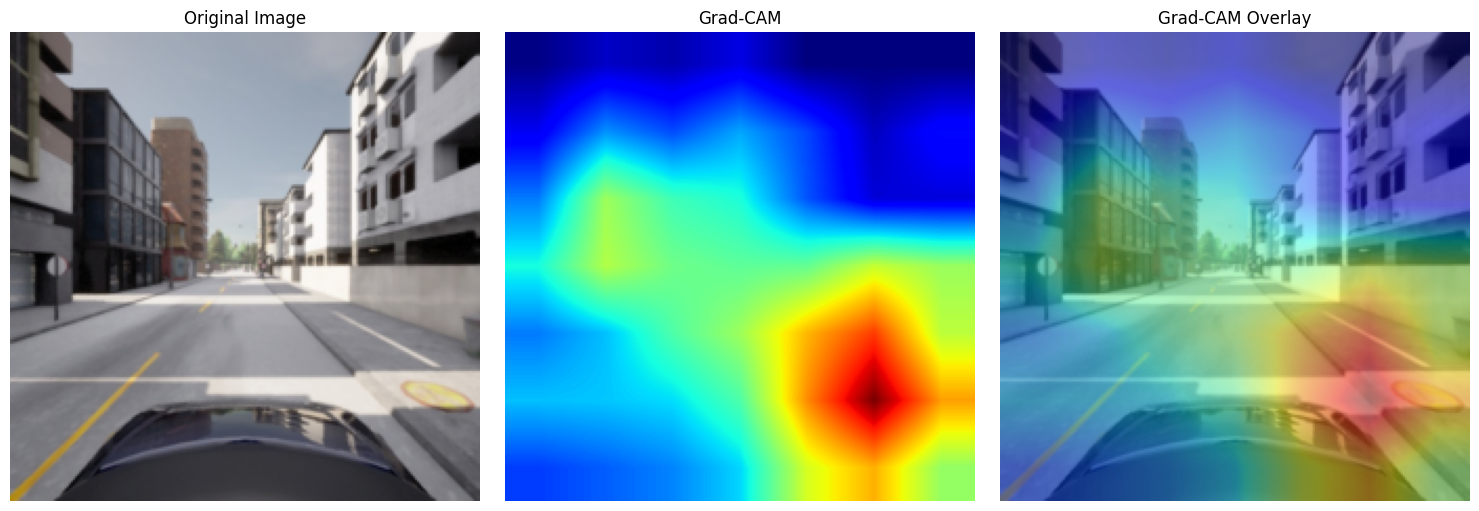


CELL 7 COMPLETE


In [7]:
# ============================================================
# EXERCISE 6.5 - CELL 7
# GRAD-CAM SINGLE IMAGE TEST
# ============================================================

print("=" * 70)
print("EXERCISE 6.5 - GRAD-CAM SINGLE IMAGE TEST")
print("=" * 70)


# ============================================================
# VISUALIZATION HELPER
# ============================================================

def denormalize_image(tensor):

    mean = torch.tensor(
        [0.485, 0.456, 0.406],
        device=tensor.device
    ).view(3, 1, 1)

    std = torch.tensor(
        [0.229, 0.224, 0.225],
        device=tensor.device
    ).view(3, 1, 1)

    image = tensor * std + mean

    image = torch.clamp(
        image,
        0,
        1
    )

    return image


# ============================================================
# LOAD ONE IMAGE
# ============================================================

sample_index = int(
    ped_eval["selected_correct"][0]
)

sample_row = test_labels_df.iloc[
    sample_index
]

sample_path = sample_row[
    "image_path"
]

print("\nSample index:")
print(sample_index)

print(
    "Frame:",
    int(sample_row["frame"])
)

print(
    "Image:",
    sample_path
)


# ============================================================
# LOAD IMAGE
# ============================================================

original_image = Image.open(
    sample_path
).convert("RGB")


input_tensor = explain_transform(
    original_image
).unsqueeze(0).to(
    device
)


print(
    "\nInput tensor shape:",
    input_tensor.shape
)

print(
    "Input device:",
    input_tensor.device
)


# ============================================================
# GENERATE GRAD-CAM
# ============================================================

cam, output, target_class = ped_gradcam.generate(
    input_tensor
)


# ============================================================
# MODEL OUTPUT
# ============================================================

probabilities = torch.softmax(
    output,
    dim=1
)[0]

prediction = int(
    torch.argmax(
        output,
        dim=1
    ).item()
)

confidence = float(
    probabilities[
        prediction
    ].item()
)


print("\n" + "-" * 60)
print("MODEL OUTPUT")
print("-" * 60)

print(
    "True label:",
    int(
        sample_row[
            "has_pedestrian"
        ]
    )
)

print(
    "Predicted class:",
    prediction
)

print(
    "Confidence:",
    f"{confidence:.4f}"
)

print(
    "P(no pedestrian):",
    f"{probabilities[0].item():.4f}"
)

print(
    "P(pedestrian):",
    f"{probabilities[1].item():.4f}"
)


# ============================================================
# CAM CHECK
# ============================================================

print("\n" + "-" * 60)
print("GRAD-CAM CHECK")
print("-" * 60)

print(
    "CAM shape:",
    cam.shape
)

print(
    "CAM minimum:",
    f"{cam.min():.6f}"
)

print(
    "CAM maximum:",
    f"{cam.max():.6f}"
)

print(
    "CAM mean:",
    f"{cam.mean():.6f}"
)


assert cam.shape == (
    224,
    224
)

assert cam.min() >= 0.0

assert cam.max() <= 1.0 + 1e-6


# ============================================================
# PREPARE DISPLAY IMAGE
# ============================================================

display_tensor = denormalize_image(
    input_tensor[0]
)

display_image = (
    display_tensor
    .permute(1, 2, 0)
    .detach()
    .cpu()
    .numpy()
)


# ============================================================
# DISPLAY ORIGINAL + GRAD-CAM
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)


# Original
axes[0].imshow(
    display_image
)

axes[0].set_title(
    "Original Image"
)

axes[0].axis(
    "off"
)


# Heatmap
axes[1].imshow(
    cam,
    cmap="jet"
)

axes[1].set_title(
    "Grad-CAM"
)

axes[1].axis(
    "off"
)


# Overlay
axes[2].imshow(
    display_image
)

axes[2].imshow(
    cam,
    cmap="jet",
    alpha=0.45
)

axes[2].set_title(
    "Grad-CAM Overlay"
)

axes[2].axis(
    "off"
)


plt.tight_layout()

plt.show()


print("\n" + "=" * 70)
print("CELL 7 COMPLETE")
print("=" * 70)

In [8]:
# ============================================================
# EXERCISE 6.5 - CELL 8
# GENERATE ALL GRAD-CAM EXPLANATIONS
# ============================================================

print("=" * 70)
print("EXERCISE 6.5 - GENERATING ALL GRAD-CAM EXPLANATIONS")
print("=" * 70)


# ============================================================
# MODEL CONFIGURATION
# ============================================================

model_configs = {

    "pedestrian": {
        "model": ped_model,
        "gradcam": ped_gradcam,
        "evaluation": ped_eval,
        "label_column": "has_pedestrian"
    },

    "traffic_light": {
        "model": traffic_light_model,
        "gradcam": traffic_gradcam,
        "evaluation": traffic_eval,
        "label_column": "has_traffic_light"
    },

    "vehicle": {
        "model": vehicle_model,
        "gradcam": vehicle_gradcam,
        "evaluation": vehicle_eval,
        "label_column": "has_vehicle"
    }
}


# ============================================================
# OUTPUT DIRECTORIES
# ============================================================

for model_name in model_configs.keys():

    model_output_dir = os.path.join(
        EXPLAINABILITY_DIR,
        model_name
    )

    correct_dir = os.path.join(
        model_output_dir,
        "correct"
    )

    incorrect_dir = os.path.join(
        model_output_dir,
        "incorrect"
    )

    os.makedirs(
        correct_dir,
        exist_ok=True
    )

    os.makedirs(
        incorrect_dir,
        exist_ok=True
    )


# ============================================================
# CLASS NAMES
# ============================================================

def get_class_name(
    model_name,
    class_id
):

    class_names = {

        "pedestrian": {
            0: "No Pedestrian",
            1: "Pedestrian"
        },

        "traffic_light": {
            0: "No Traffic Light",
            1: "Traffic Light"
        },

        "vehicle": {
            0: "No Vehicle",
            1: "Vehicle"
        }
    }

    return class_names[
        model_name
    ][
        int(class_id)
    ]


# ============================================================
# GENERATE ONE EXPLANATION
# ============================================================

def generate_explanation(
    model_name,
    config,
    sample_index,
    sample_type,
    sample_number
):

    model = config["model"]

    gradcam = config["gradcam"]

    evaluation = config["evaluation"]

    label_column = config["label_column"]


    # --------------------------------------------------------
    # Get dataframe row
    # --------------------------------------------------------

    row = test_labels_df.iloc[
        int(sample_index)
    ]


    frame = int(
        row["frame"]
    )

    image_path = row[
        "image_path"
    ]


    true_label = int(
        bool(
            row[
                label_column
            ]
        )
    )


    # --------------------------------------------------------
    # Load image
    # --------------------------------------------------------

    original_image = Image.open(
        image_path
    ).convert("RGB")


    input_tensor = explain_transform(
        original_image
    ).unsqueeze(
        0
    ).to(
        device
    )


    # --------------------------------------------------------
    # Generate Grad-CAM
    # --------------------------------------------------------

    cam, output, target_class = (
        gradcam.generate(
            input_tensor
        )
    )


    # --------------------------------------------------------
    # Probabilities
    # --------------------------------------------------------

    probabilities = torch.softmax(
        output,
        dim=1
    )[0]


    prediction = int(
        torch.argmax(
            output,
            dim=1
        ).item()
    )


    confidence = float(
        probabilities[
            prediction
        ].item()
    )


    positive_probability = float(
        probabilities[1].item()
    )


    # --------------------------------------------------------
    # Prepare display image
    # --------------------------------------------------------

    display_tensor = denormalize_image(
        input_tensor[0]
    )


    display_image = (
        display_tensor
        .permute(1, 2, 0)
        .detach()
        .cpu()
        .numpy()
    )


    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )


    # Original
    axes[0].imshow(
        display_image
    )

    axes[0].set_title(
        "Original Image"
    )

    axes[0].axis(
        "off"
    )


    # Grad-CAM
    axes[1].imshow(
        cam,
        cmap="jet"
    )

    axes[1].set_title(
        "Grad-CAM"
    )

    axes[1].axis(
        "off"
    )


    # Overlay
    axes[2].imshow(
        display_image
    )

    axes[2].imshow(
        cam,
        cmap="jet",
        alpha=0.45
    )

    axes[2].set_title(
        "Grad-CAM Overlay"
    )

    axes[2].axis(
        "off"
    )


    # --------------------------------------------------------
    # Overall title
    # --------------------------------------------------------

    status = (
        "CORRECT"
        if prediction == true_label
        else "MISCLASSIFIED"
    )


    true_name = get_class_name(
        model_name,
        true_label
    )

    predicted_name = get_class_name(
        model_name,
        prediction
    )


    fig.suptitle(
        (
            f"{model_name.replace('_', ' ').title()} | "
            f"Frame {frame:06d} | {status}\n"
            f"True: {true_name} | "
            f"Predicted: {predicted_name} | "
            f"Confidence: {confidence:.4f} | "
            f"P(Positive): {positive_probability:.4f}"
        ),
        fontsize=12
    )


    plt.tight_layout(
        rect=[0, 0, 1, 0.90]
    )


    # --------------------------------------------------------
    # Save figure
    # --------------------------------------------------------

    output_dir = os.path.join(

        EXPLAINABILITY_DIR,

        model_name,

        sample_type
    )


    output_filename = (
        f"{sample_type}_"
        f"{sample_number:02d}_"
        f"frame_{frame:06d}.png"
    )


    output_path = os.path.join(
        output_dir,
        output_filename
    )


    plt.savefig(
        output_path,
        dpi=150,
        bbox_inches="tight"
    )


    plt.close(
        fig
    )


    return {

        "model": model_name,

        "sample_type": sample_type,

        "sample_number": sample_number,

        "index": int(sample_index),

        "frame": frame,

        "true_label": true_label,

        "prediction": prediction,

        "confidence": confidence,

        "positive_probability":
            positive_probability,

        "cam_mean":
            float(cam.mean()),

        "cam_max":
            float(cam.max()),

        "output_path":
            output_path
    }


# ============================================================
# GENERATE ALL EXPLANATIONS
# ============================================================

explainability_records = []


for model_name, config in model_configs.items():

    print("\n" + "-" * 70)

    print(
        f"MODEL: {model_name.upper()}"
    )

    print("-" * 70)


    evaluation = config[
        "evaluation"
    ]


    # --------------------------------------------------------
    # Correct samples
    # --------------------------------------------------------

    correct_samples = evaluation[
        "selected_correct"
    ]


    print(
        "\nGenerating correct samples..."
    )


    for number, index in enumerate(
        correct_samples,
        start=1
    ):

        record = generate_explanation(

            model_name,

            config,

            int(index),

            "correct",

            number
        )


        explainability_records.append(
            record
        )


        print(
            f"  Correct {number}/5 "
            f"-> frame "
            f"{record['frame']:06d}"
        )


    # --------------------------------------------------------
    # Incorrect samples
    # --------------------------------------------------------

    incorrect_samples = evaluation[
        "selected_incorrect"
    ]


    print(
        "\nGenerating incorrect samples..."
    )


    for number, index in enumerate(
        incorrect_samples,
        start=1
    ):

        record = generate_explanation(

            model_name,

            config,

            int(index),

            "incorrect",

            number
        )


        explainability_records.append(
            record
        )


        print(
            f"  Incorrect {number}/3 "
            f"-> frame "
            f"{record['frame']:06d}"
        )


# ============================================================
# CREATE SUMMARY DATAFRAME
# ============================================================

explainability_df = pd.DataFrame(
    explainability_records
)


summary_path = os.path.join(
    EXPLAINABILITY_DIR,
    "gradcam_summary.csv"
)


explainability_df.to_csv(
    summary_path,
    index=False
)


# ============================================================
# FINAL CHECK
# ============================================================

print("\n" + "-" * 70)
print("GENERATION SUMMARY")
print("-" * 70)

print(
    "Total explanations:",
    len(explainability_df)
)

print(
    "Expected explanations:",
    24
)

print(
    "Correct explanations:",
    len(
        explainability_df[
            explainability_df[
                "sample_type"
            ] == "correct"
        ]
    )
)

print(
    "Incorrect explanations:",
    len(
        explainability_df[
            explainability_df[
                "sample_type"
            ] == "incorrect"
        ]
    )
)

print(
    "\nSummary saved to:"
)

print(
    summary_path
)


# ============================================================
# ASSERTIONS
# ============================================================

assert len(
    explainability_df
) == 24

assert len(
    explainability_df[
        explainability_df[
            "sample_type"
        ] == "correct"
    ]
) == 15

assert len(
    explainability_df[
        explainability_df[
            "sample_type"
        ] == "incorrect"
    ]
) == 9


print("\n" + "=" * 70)
print("CELL 8 COMPLETE")
print("=" * 70)

EXERCISE 6.5 - GENERATING ALL GRAD-CAM EXPLANATIONS

----------------------------------------------------------------------
MODEL: PEDESTRIAN
----------------------------------------------------------------------

Generating correct samples...
  Correct 1/5 -> frame 000000
  Correct 2/5 -> frame 000010
  Correct 3/5 -> frame 000020
  Correct 4/5 -> frame 000030
  Correct 5/5 -> frame 000040

Generating incorrect samples...
  Incorrect 1/3 -> frame 001050
  Incorrect 2/3 -> frame 001060
  Incorrect 3/3 -> frame 001190

----------------------------------------------------------------------
MODEL: TRAFFIC_LIGHT
----------------------------------------------------------------------

Generating correct samples...
  Correct 1/5 -> frame 000000
  Correct 2/5 -> frame 000010
  Correct 3/5 -> frame 000020
  Correct 4/5 -> frame 000030
  Correct 5/5 -> frame 000040

Generating incorrect samples...
  Incorrect 1/3 -> frame 000120
  Incorrect 2/3 -> frame 000130
  Incorrect 3/3 -> frame 000160

--

EXERCISE 6.5 - GRAD-CAM CONTACT SHEETS

Generating contact sheet: pedestrian


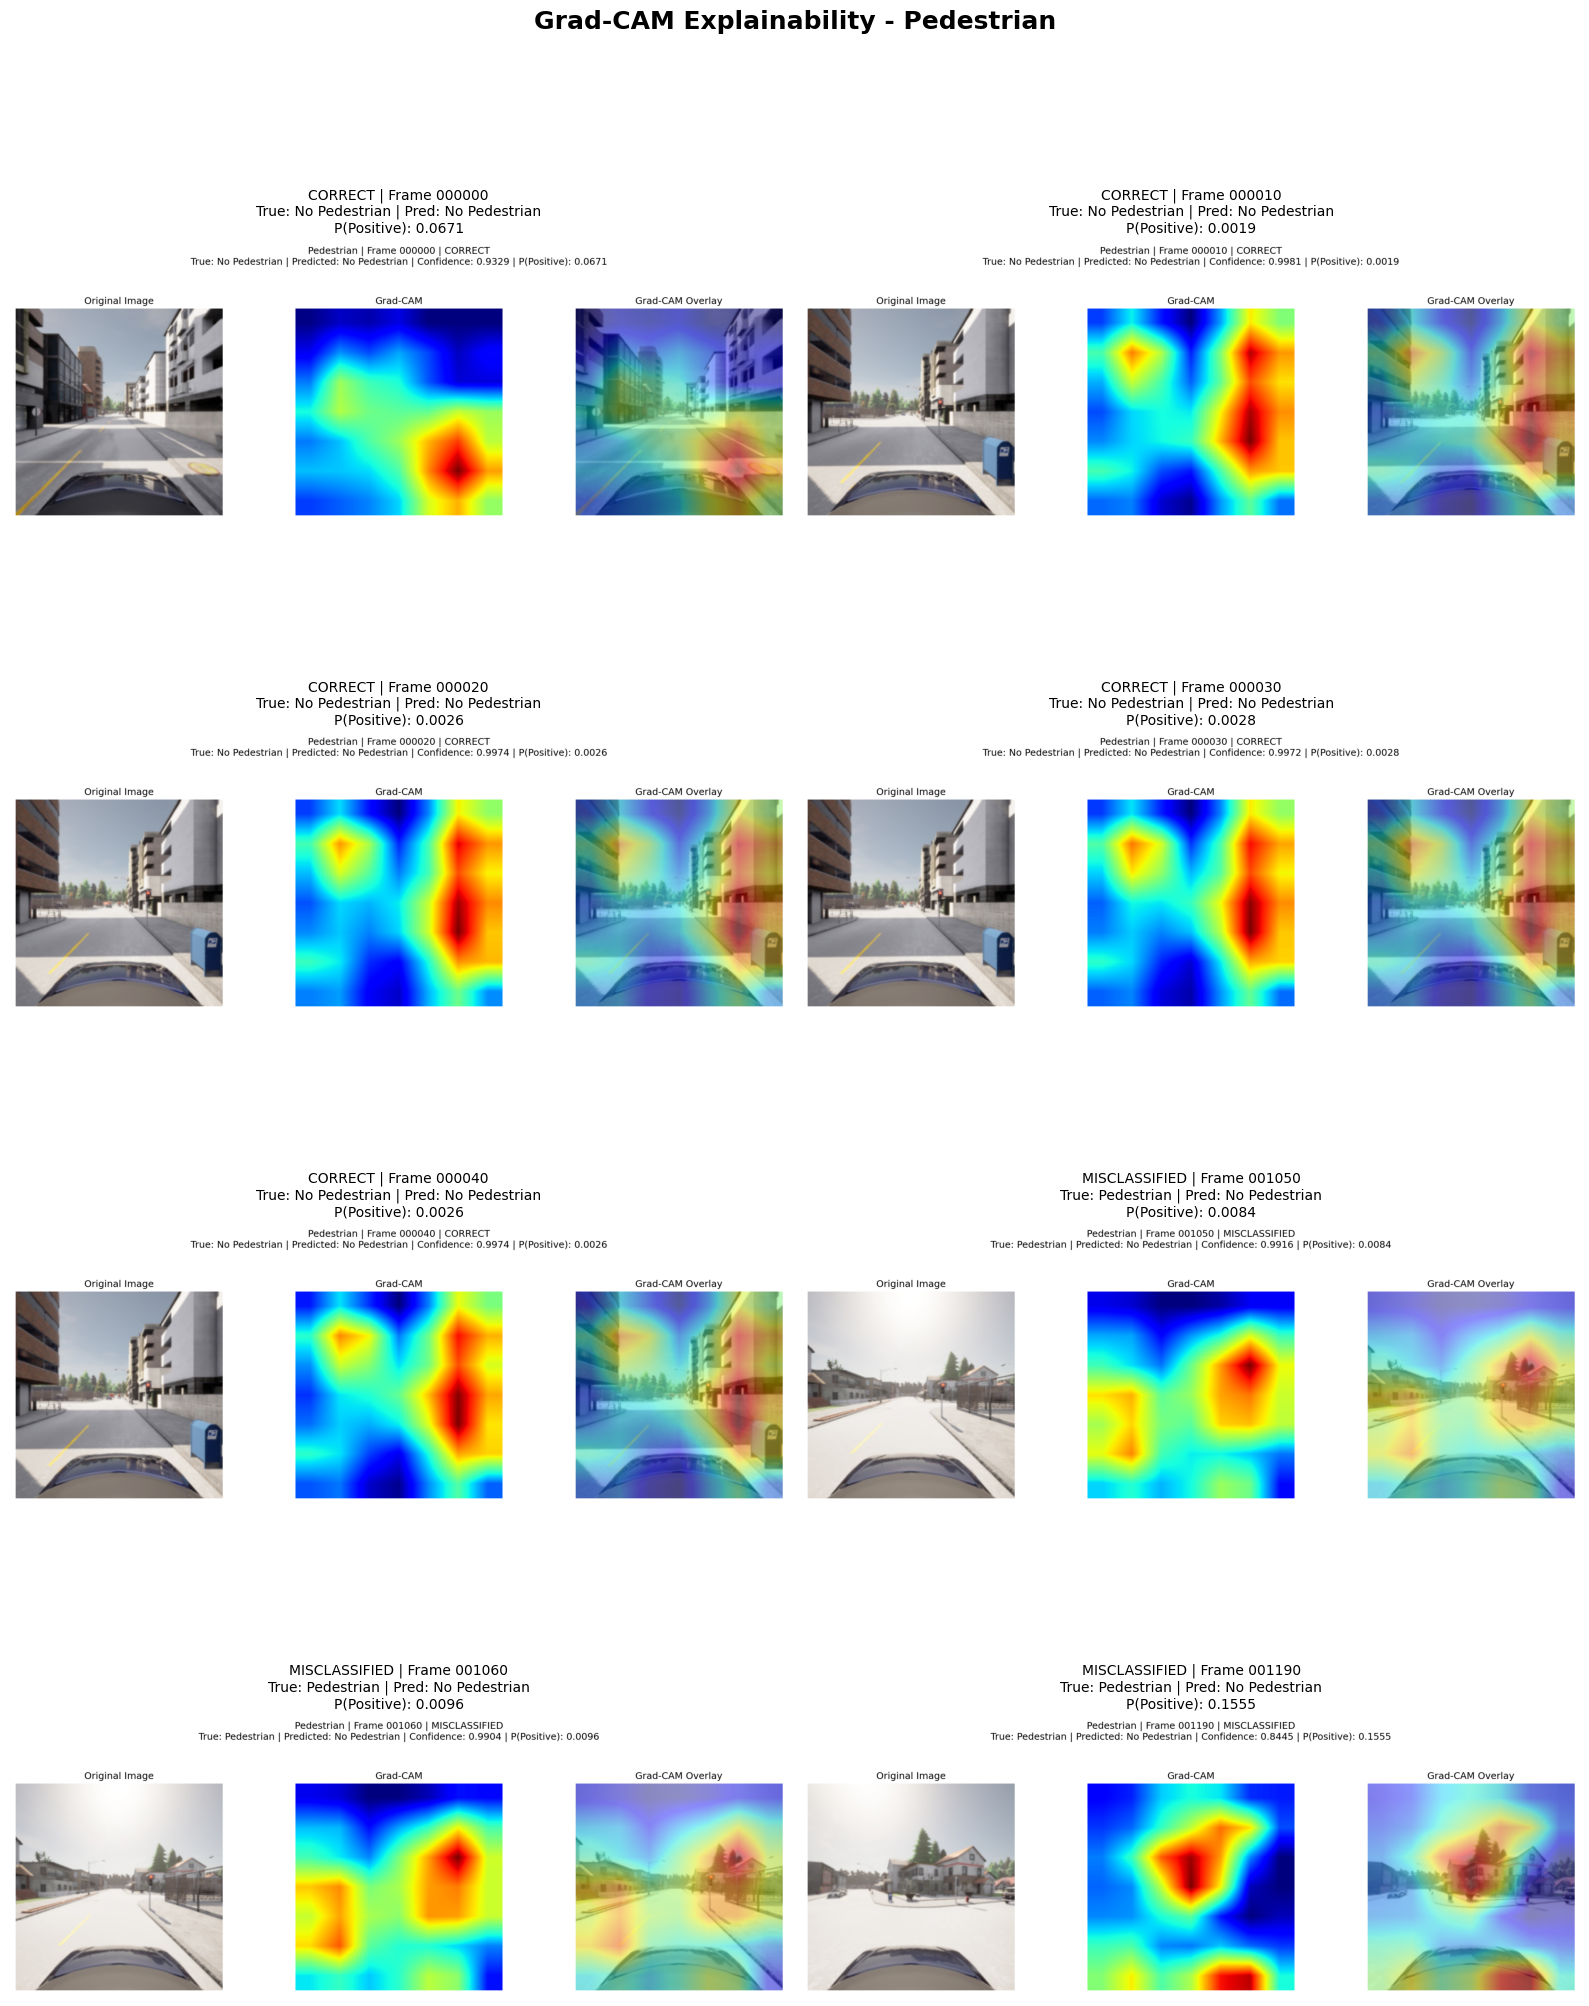

Saved: E:\ML_Safety\explainability_results\pedestrian_gradcam_contact_sheet.png

Generating contact sheet: traffic_light


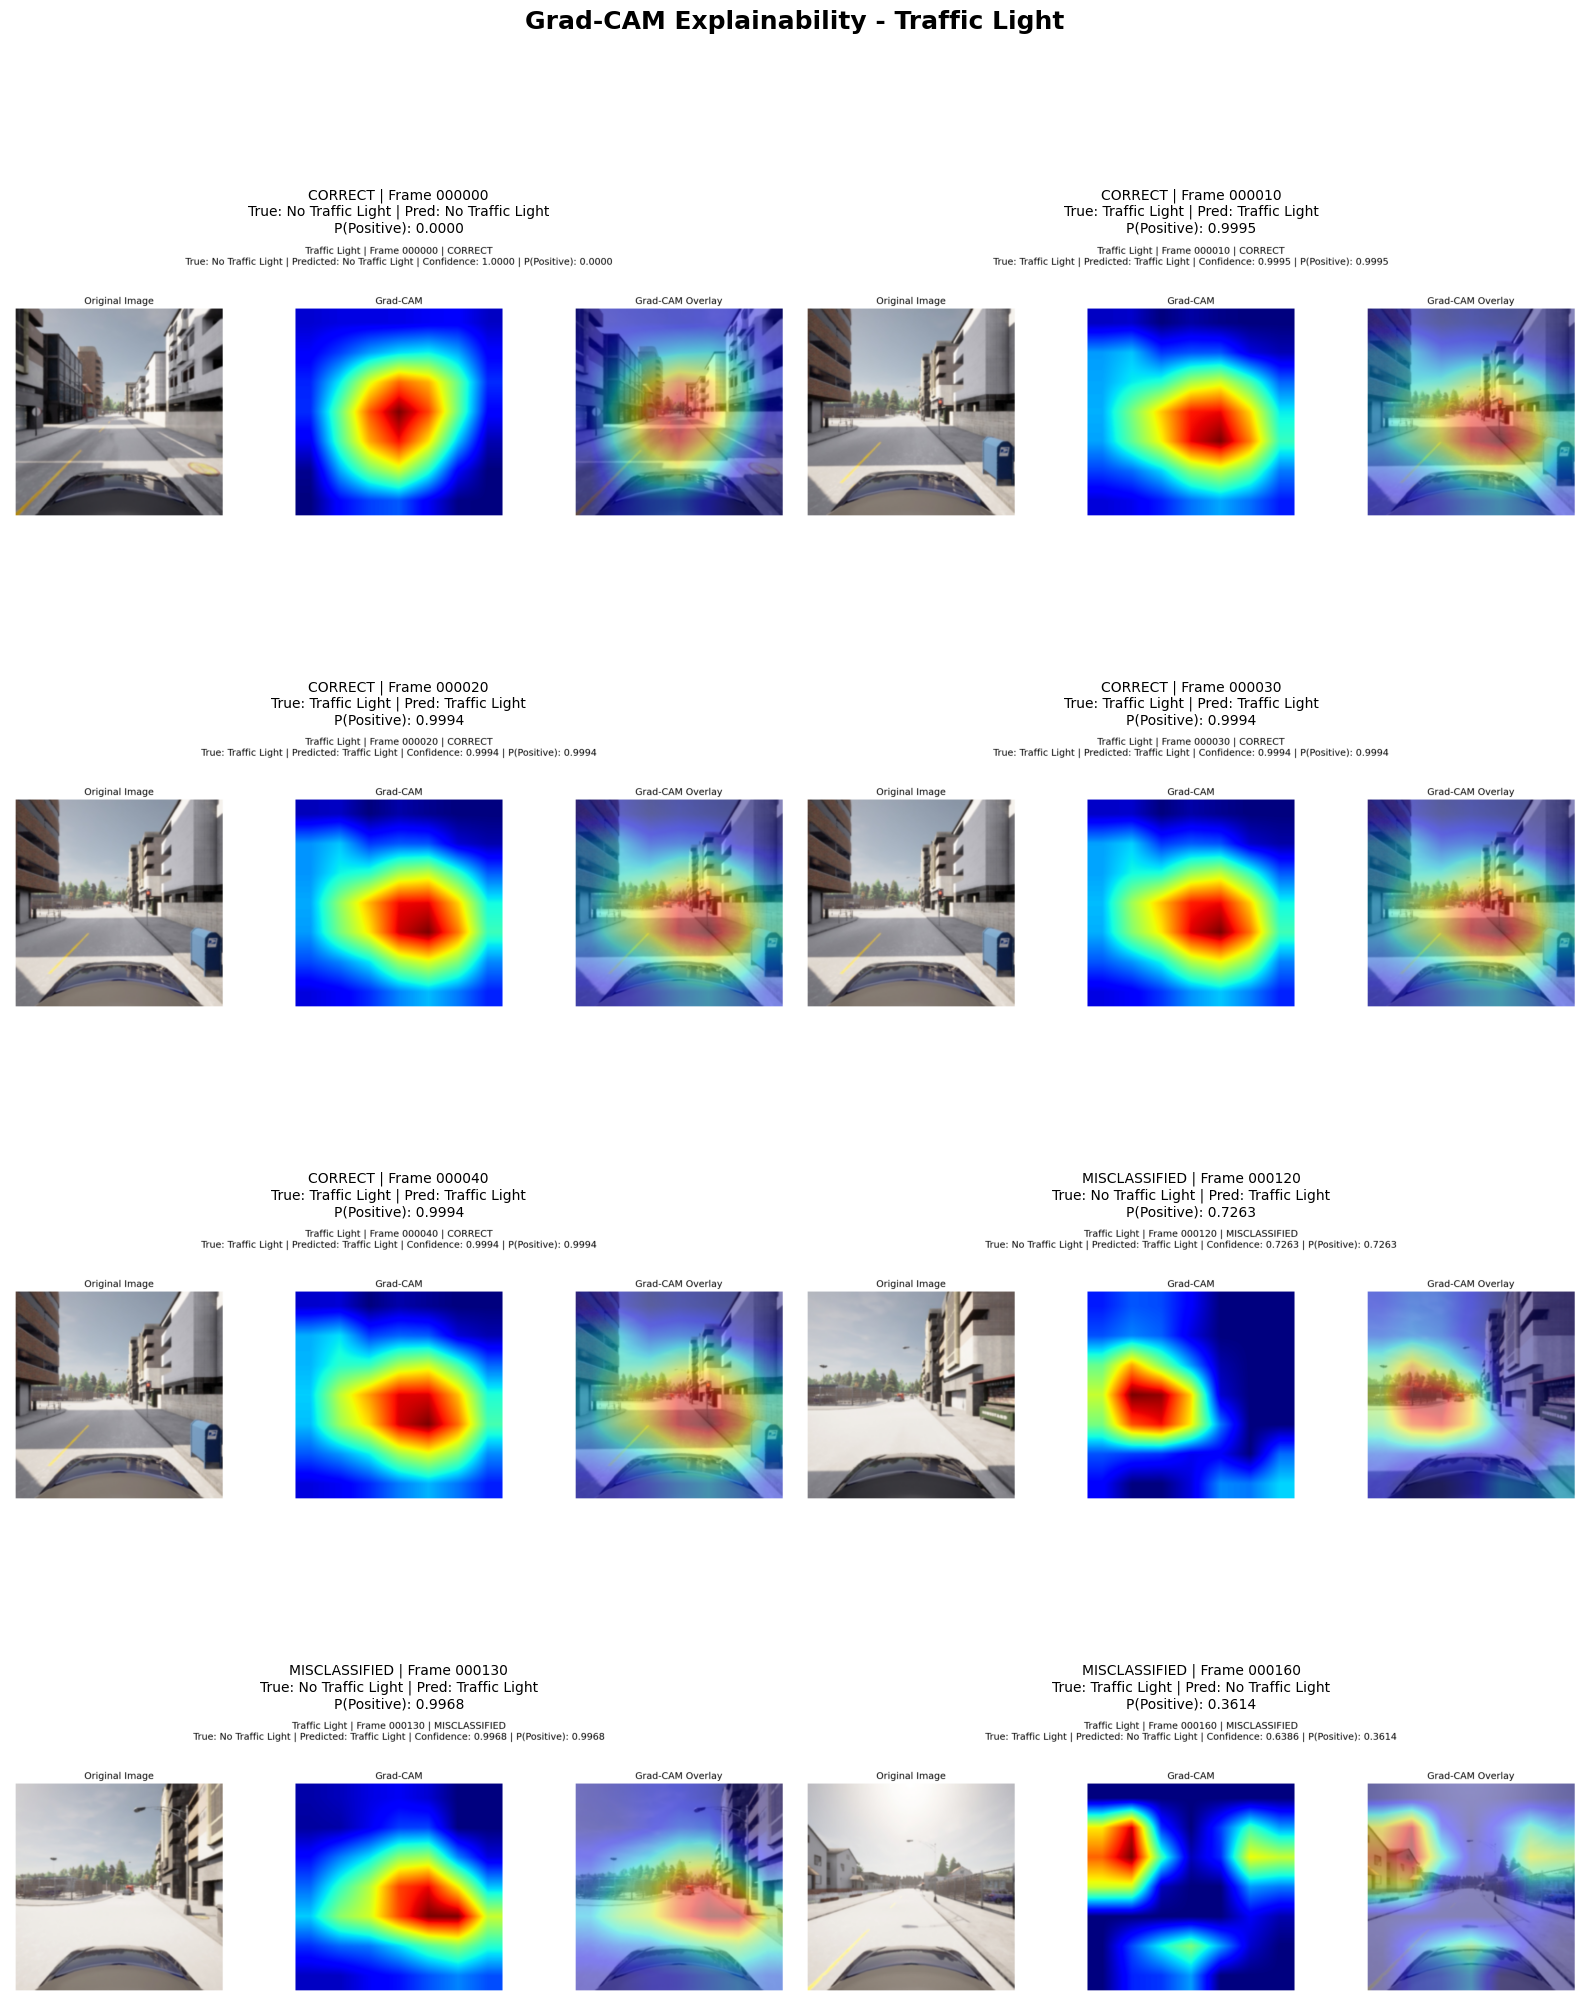

Saved: E:\ML_Safety\explainability_results\traffic_light_gradcam_contact_sheet.png

Generating contact sheet: vehicle


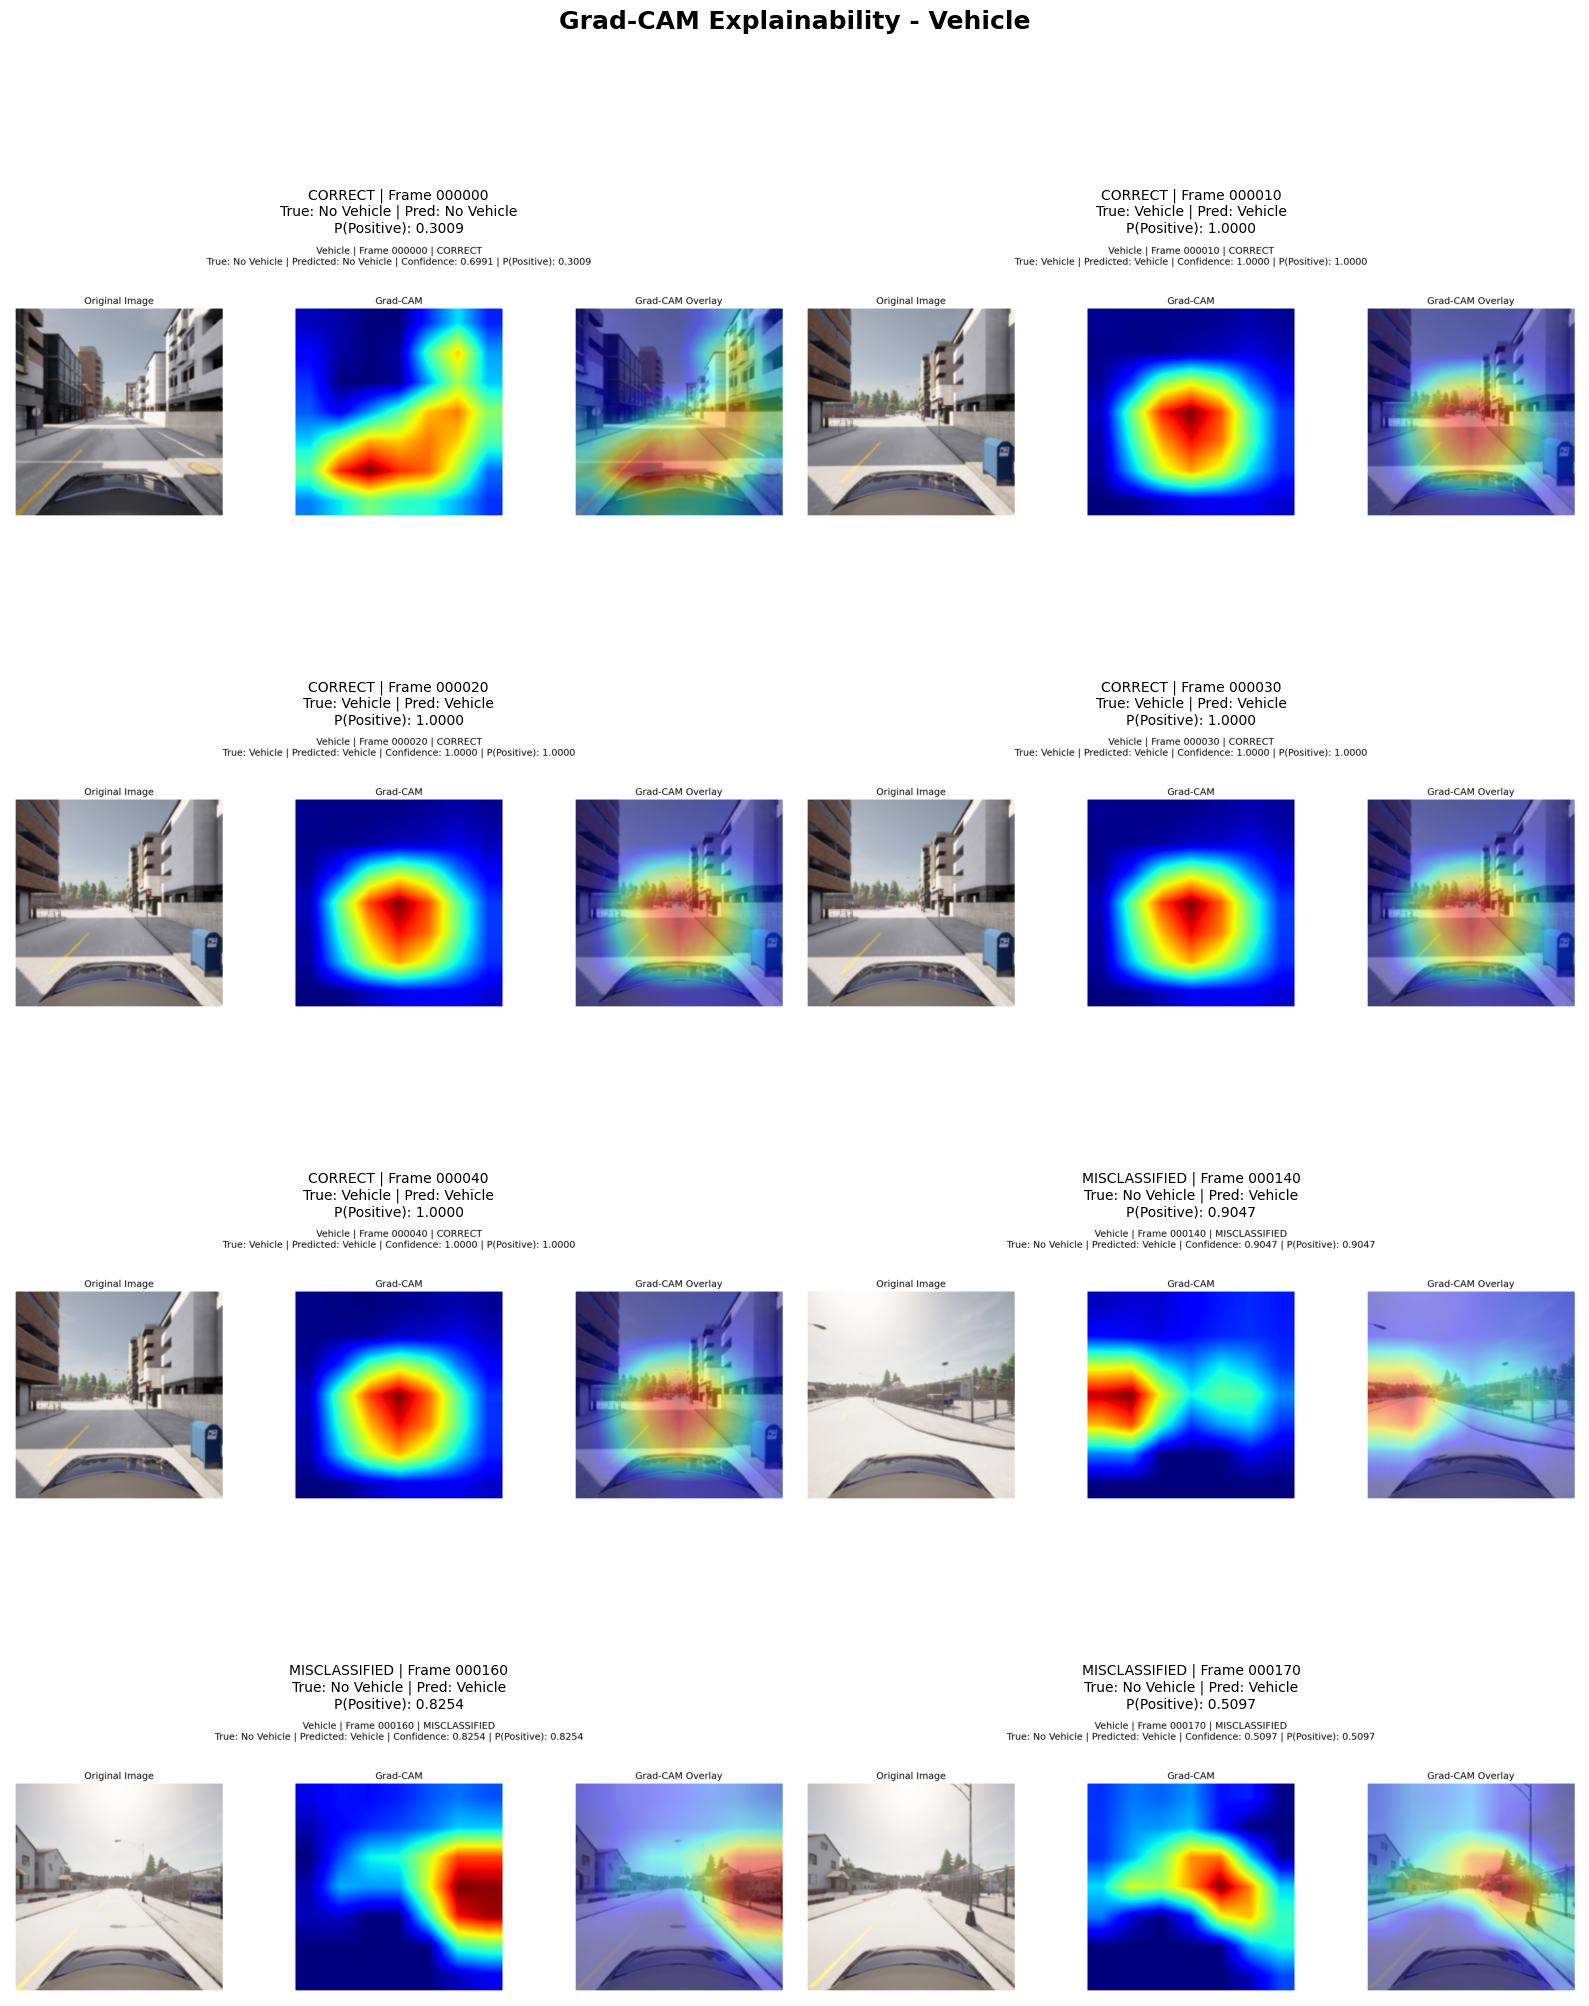

Saved: E:\ML_Safety\explainability_results\vehicle_gradcam_contact_sheet.png

----------------------------------------------------------------------
CONTACT SHEET SUMMARY
----------------------------------------------------------------------
Contact sheets created: 3
E:\ML_Safety\explainability_results\pedestrian_gradcam_contact_sheet.png
E:\ML_Safety\explainability_results\traffic_light_gradcam_contact_sheet.png
E:\ML_Safety\explainability_results\vehicle_gradcam_contact_sheet.png

CELL 9 COMPLETE


In [9]:
# ============================================================
# EXERCISE 6.5 - CELL 9
# CREATE GRAD-CAM CONTACT SHEETS
# ============================================================

print("=" * 70)
print("EXERCISE 6.5 - GRAD-CAM CONTACT SHEETS")
print("=" * 70)


# ============================================================
# CONTACT SHEET FUNCTION
# ============================================================

def create_contact_sheet(
    model_name,
    records,
    output_dir
):

    model_records = records[
        records["model"] == model_name
    ].copy()


    # Sort:
    # correct first, then incorrect
    # and by sample number
    model_records["type_order"] = (
        model_records["sample_type"]
        .map({
            "correct": 0,
            "incorrect": 1
        })
    )


    model_records = (
        model_records
        .sort_values(
            ["type_order", "sample_number"]
        )
    )


    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        4,
        2,
        figsize=(16, 22)
    )


    axes = axes.flatten()


    for ax, (_, record) in zip(
        axes,
        model_records.iterrows()
    ):

        image_path = record[
            "output_path"
        ]


        # Load saved Grad-CAM figure
        image = Image.open(
            image_path
        )


        ax.imshow(
            image
        )


        status = (
            "CORRECT"
            if record["sample_type"]
            == "correct"
            else "MISCLASSIFIED"
        )


        true_name = get_class_name(
            model_name,
            record["true_label"]
        )


        predicted_name = get_class_name(
            model_name,
            record["prediction"]
        )


        ax.set_title(
            (
                f"{status} | "
                f"Frame {int(record['frame']):06d}\n"
                f"True: {true_name} | "
                f"Pred: {predicted_name}\n"
                f"P(Positive): "
                f"{record['positive_probability']:.4f}"
            ),
            fontsize=10
        )


        ax.axis(
            "off"
        )


    # Hide unused axes if any
    for ax in axes[len(model_records):]:

        ax.axis(
            "off"
        )


    fig.suptitle(
        (
            f"Grad-CAM Explainability - "
            f"{model_name.replace('_', ' ').title()}"
        ),
        fontsize=18,
        fontweight="bold"
    )


    plt.tight_layout(
        rect=[0, 0, 1, 0.97]
    )


    output_path = os.path.join(
        output_dir,
        f"{model_name}_gradcam_contact_sheet.png"
    )


    plt.savefig(
        output_path,
        dpi=150,
        bbox_inches="tight"
    )


    plt.show()

    plt.close(
        fig
    )


    return output_path


# ============================================================
# GENERATE CONTACT SHEETS
# ============================================================

contact_sheet_paths = []


for model_name in model_configs.keys():

    print(
        f"\nGenerating contact sheet: "
        f"{model_name}"
    )


    path = create_contact_sheet(
        model_name=model_name,
        records=explainability_df,
        output_dir=EXPLAINABILITY_DIR
    )


    contact_sheet_paths.append(
        path
    )


    print(
        "Saved:",
        path
    )


# ============================================================
# SUMMARY
# ============================================================

print("\n" + "-" * 70)
print("CONTACT SHEET SUMMARY")
print("-" * 70)

print(
    "Contact sheets created:",
    len(contact_sheet_paths)
)


for path in contact_sheet_paths:

    print(
        path
    )


print("\n" + "=" * 70)
print("CELL 9 COMPLETE")
print("=" * 70)

In [10]:
# ============================================================
# EXERCISE 6.6 - CELL 10
# MODEL PERFORMANCE ACROSS CONDITIONS
# ============================================================

print("=" * 70)
print("EXERCISE 6.6 - MODEL PERFORMANCE ACROSS CONDITIONS")
print("=" * 70)


# ============================================================
# CONDITION CONFIGURATION
# ============================================================

condition_configs = {

    "test": {
        "directory": TEST_DIR,
        "label_file": os.path.join(
            TEST_DIR,
            "labels.feather"
        )
    },

    "test-fog": {
        "directory": FOG_DIR,
        "label_file": os.path.join(
            FOG_DIR,
            "labels.feather"
        )
    },

    "test-night": {
        "directory": NIGHT_DIR,
        "label_file": os.path.join(
            NIGHT_DIR,
            "labels.feather"
        )
    },

    "test-town-01": {
        "directory": TOWN_DIR,
        "label_file": os.path.join(
            TOWN_DIR,
            "labels.feather"
        )
    }
}


# ============================================================
# MODEL CONFIGURATION
# ============================================================

condition_models = {

    "Pedestrian": {
        "model": ped_model,
        "label_column": "has_pedestrian"
    },

    "Traffic Light": {
        "model": traffic_light_model,
        "label_column": "has_traffic_light"
    },

    "Vehicle": {
        "model": vehicle_model,
        "label_column": "has_vehicle"
    }
}


# ============================================================
# EVALUATION FUNCTION
# ============================================================

def evaluate_condition(
    model,
    dataframe,
    label_column,
    transform
):

    dataset = CarlaExplainabilityDataset(
        dataframe=dataframe,
        label_column=label_column,
        transform=transform
    )

    loader = DataLoader(
        dataset,
        batch_size=64,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )


    predictions = []
    labels = []
    probabilities = []


    model.eval()


    with torch.no_grad():

        for images, batch_labels, _ in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            outputs = model(
                images
            )

            probs = torch.softmax(
                outputs,
                dim=1
            )[:, 1]

            preds = (
                probs >= 0.5
            ).long()


            predictions.extend(
                preds.cpu().numpy()
            )

            labels.extend(
                batch_labels.numpy()
            )

            probabilities.extend(
                probs.cpu().numpy()
            )


    predictions = np.asarray(
        predictions
    )

    labels = np.asarray(
        labels
    )

    probabilities = np.asarray(
        probabilities
    )


    # --------------------------------------------------------
    # Confusion matrix values
    # --------------------------------------------------------

    tn = int(
        np.sum(
            (labels == 0) &
            (predictions == 0)
        )
    )

    fp = int(
        np.sum(
            (labels == 0) &
            (predictions == 1)
        )
    )

    fn = int(
        np.sum(
            (labels == 1) &
            (predictions == 0)
        )
    )

    tp = int(
        np.sum(
            (labels == 1) &
            (predictions == 1)
        )
    )


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    accuracy = (
        (tp + tn) /
        len(labels)
    )


    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0.0
    )


    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )


    f1 = (
        2 * precision * recall /
        (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )


    return {

        "accuracy": accuracy,

        "precision": precision,

        "recall": recall,

        "f1": f1,

        "tn": tn,

        "fp": fp,

        "fn": fn,

        "tp": tp,

        "labels": labels,

        "predictions": predictions,

        "probabilities": probabilities
    }


# ============================================================
# LOAD EACH CONDITION
# ============================================================

condition_dataframes = {}


for condition_name, config in condition_configs.items():

    print("\n" + "-" * 70)

    print(
        f"LOADING CONDITION: {condition_name}"
    )

    print("-" * 70)


    label_file = config[
        "label_file"
    ]

    directory = config[
        "directory"
    ]


    print(
        "Directory:",
        directory
    )

    print(
        "Label file:",
        label_file
    )

    print(
        "Directory exists:",
        os.path.exists(directory)
    )

    print(
        "Labels exist:",
        os.path.exists(label_file)
    )


    assert os.path.exists(
        directory
    ), (
        f"Missing directory: {directory}"
    )

    assert os.path.exists(
        label_file
    ), (
        f"Missing labels: {label_file}"
    )


    df = pd.read_feather(
        label_file
    )


    # Build image lookup
    rgb_dir = os.path.join(
        directory,
        "rgb-front"
    )


    image_lookup_condition = {}


    for filename in os.listdir(
        rgb_dir
    ):

        if filename.lower().endswith(
            ".jpg"
        ):

            stem = os.path.splitext(
                filename
            )[0]

            try:

                frame = int(stem)

                image_lookup_condition[
                    frame
                ] = os.path.join(
                    rgb_dir,
                    filename
                )

            except ValueError:

                pass


    df["image_path"] = (
        df["frame"]
        .astype(int)
        .map(
            image_lookup_condition
        )
    )


    missing = int(
        df["image_path"].isna().sum()
    )


    print(
        "Number of labels:",
        len(df)
    )

    print(
        "Images found:",
        len(image_lookup_condition)
    )

    print(
        "Missing images:",
        missing
    )


    assert missing == 0, (
        f"{missing} images missing "
        f"for {condition_name}"
    )


    condition_dataframes[
        condition_name
    ] = df


# ============================================================
# EVALUATE ALL CONDITIONS × MODELS
# ============================================================

evaluation_rows = []


for condition_name, df in (
    condition_dataframes.items()
):

    print("\n" + "=" * 70)

    print(
        f"CONDITION: {condition_name}"
    )

    print("=" * 70)


    for model_name, config in (
        condition_models.items()
    ):

        result = evaluate_condition(

            model=config["model"],

            dataframe=df,

            label_column=config[
                "label_column"
            ],

            transform=explain_transform
        )


        evaluation_rows.append({

            "Condition":
                condition_name,

            "Model":
                model_name,

            "Accuracy":
                result["accuracy"],

            "Precision":
                result["precision"],

            "Recall":
                result["recall"],

            "F1":
                result["f1"],

            "TP":
                result["tp"],

            "TN":
                result["tn"],

            "FP":
                result["fp"],

            "FN":
                result["fn"]
        })


        print(
            f"{model_name:15s} | "
            f"Accuracy={result['accuracy']:.4f} | "
            f"Precision={result['precision']:.4f} | "
            f"Recall={result['recall']:.4f} | "
            f"F1={result['f1']:.4f}"
        )


# ============================================================
# RESULTS DATAFRAME
# ============================================================

condition_metrics_df = pd.DataFrame(
    evaluation_rows
)


print("\n" + "=" * 70)
print("CONDITION PERFORMANCE SUMMARY")
print("=" * 70)


display(
    condition_metrics_df[
        [
            "Condition",
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1"
        ]
    ]
)


# ============================================================
# SAVE RESULTS
# ============================================================

condition_metrics_path = os.path.join(
    EXPLAINABILITY_DIR,
    "exercise6_condition_metrics.csv"
)


condition_metrics_df.to_csv(
    condition_metrics_path,
    index=False
)


print(
    "\nSaved metrics to:"
)

print(
    condition_metrics_path
)


print("\n" + "=" * 70)
print("CELL 10 COMPLETE")
print("=" * 70)

EXERCISE 6.6 - MODEL PERFORMANCE ACROSS CONDITIONS

----------------------------------------------------------------------
LOADING CONDITION: test
----------------------------------------------------------------------
Directory: E:\ML_Safety\test
Label file: E:\ML_Safety\test\labels.feather
Directory exists: True
Labels exist: True
Number of labels: 3600
Images found: 3600
Missing images: 0

----------------------------------------------------------------------
LOADING CONDITION: test-fog
----------------------------------------------------------------------
Directory: E:\ML_Safety\test-fog
Label file: E:\ML_Safety\test-fog\labels.feather
Directory exists: True
Labels exist: True
Number of labels: 3600
Images found: 3600
Missing images: 0

----------------------------------------------------------------------
LOADING CONDITION: test-night
----------------------------------------------------------------------
Directory: E:\ML_Safety\test-night
Label file: E:\ML_Safety\test-night\labels.

,Condition,Model,Accuracy,Precision,Recall,F1
0,test,Pedestrian,0.791389,0.383420,0.104816,0.164627
1,test,Traffic Light,0.937500,0.937987,0.977554,0.957362
2,test,Vehicle,0.884167,0.915242,0.931852,0.923472
3,test-fog,Pedestrian,0.796389,0.000000,0.000000,0.000000
4,test-fog,Traffic Light,0.719444,0.962772,0.640137,0.768984
5,test-fog,Vehicle,0.661111,0.985121,0.570557,0.722601
6,test-night,Pedestrian,0.788056,0.228070,0.017760,0.032953
7,test-night,Traffic Light,0.270556,1.000000,0.000381,0.000761
8,test-night,Vehicle,0.823056,0.856574,0.926391,0.890116
9,test-town-01,Pedestrian,0.897778,0.347518,0.150769,0.210300



Saved metrics to:
E:\ML_Safety\explainability_results\exercise6_condition_metrics.csv

CELL 10 COMPLETE


In [12]:
# ============================================================
# EXERCISE 6.6 - OPENCV IMPORT
# ============================================================

import cv2

print("=" * 70)
print("OpenCV CHECK")
print("=" * 70)

print("OpenCV version:", cv2.__version__)
print("cv2 imported successfully!")

print("=" * 70)
print("IMPORT CELL COMPLETE")
print("=" * 70)

OpenCV CHECK
OpenCV version: 4.9.0
cv2 imported successfully!
IMPORT CELL COMPLETE


In [13]:
# ============================================================
# EXERCISE 6.6 - CELL 11
# GRAD-CAM ACROSS CONDITIONS
# ============================================================

print("=" * 70)
print("EXERCISE 6.6 - GRAD-CAM ACROSS CONDITIONS")
print("=" * 70)


# ============================================================
# OUTPUT DIRECTORY
# ============================================================

CONDITION_GRADCAM_DIR = os.path.join(
    EXPLAINABILITY_DIR,
    "condition_gradcam"
)

os.makedirs(
    CONDITION_GRADCAM_DIR,
    exist_ok=True
)


# ============================================================
# MODEL CONFIGURATION
# ============================================================

gradcam_models = {

    "Pedestrian": {
        "model": ped_model,
        "label_column": "has_pedestrian"
    },

    "Traffic Light": {
        "model": traffic_light_model,
        "label_column": "has_traffic_light"
    },

    "Vehicle": {
        "model": vehicle_model,
        "label_column": "has_vehicle"
    }
}


# ============================================================
# GRAD-CAM IMPLEMENTATION
# ============================================================

class SimpleGradCAM:

    def __init__(self, model, target_layer):

        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.forward_handle = (
            target_layer.register_forward_hook(
                self._forward_hook
            )
        )

        self.backward_handle = (
            target_layer.register_full_backward_hook(
                self._backward_hook
            )
        )


    def _forward_hook(
        self,
        module,
        inputs,
        output
    ):

        self.activations = output


    def _backward_hook(
        self,
        module,
        grad_input,
        grad_output
    ):

        self.gradients = grad_output[0]


    def generate(
        self,
        input_tensor,
        target_class
    ):

        self.model.zero_grad(
            set_to_none=True
        )


        output = self.model(
            input_tensor
        )


        score = output[
            0,
            target_class
        ]


        score.backward()


        activations = (
            self.activations
        )

        gradients = (
            self.gradients
        )


        # ----------------------------------------------------
        # Global average pooling of gradients
        # ----------------------------------------------------

        weights = gradients.mean(
            dim=(2, 3),
            keepdim=True
        )


        # ----------------------------------------------------
        # Weighted activation maps
        # ----------------------------------------------------

        cam = (
            weights * activations
        ).sum(
            dim=1
        )


        cam = torch.relu(
            cam
        )


        # ----------------------------------------------------
        # Normalize CAM
        # ----------------------------------------------------

        cam = cam[0]

        cam -= cam.min()

        if cam.max() > 0:

            cam /= cam.max()


        cam = cam.detach().cpu().numpy()


        # ----------------------------------------------------
        # Resize CAM to image size
        # ----------------------------------------------------

        cam = cv2.resize(
            cam,
            (224, 224),
            interpolation=cv2.INTER_LINEAR
        )


        return cam, output.detach()


    def close(self):

        self.forward_handle.remove()
        self.backward_handle.remove()


# ============================================================
# TARGET LAYERS
# ============================================================

target_layers = {

    "Pedestrian":
        ped_model.layer4,

    "Traffic Light":
        traffic_light_model.layer4,

    "Vehicle":
        vehicle_model.layer4
}


# ============================================================
# HELPER: LOAD IMAGE
# ============================================================

def load_condition_image(
    image_path
):

    image = Image.open(
        image_path
    ).convert("RGB")

    transformed = explain_transform(
        image
    )

    return (
        image,
        transformed.unsqueeze(0)
    )


# ============================================================
# HELPER: CREATE OVERLAY
# ============================================================

def create_gradcam_overlay(
    original_image,
    cam
):

    original = np.asarray(
        original_image.resize(
            (224, 224)
        )
    ).astype(
        np.float32
    ) / 255.0


    heatmap = np.uint8(
        255 * cam
    )


    heatmap = cv2.applyColorMap(
        heatmap,
        cv2.COLORMAP_JET
    )


    heatmap = cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB
    )


    heatmap = (
        heatmap.astype(
            np.float32
        ) / 255.0
    )


    overlay = (
        0.55 * original +
        0.45 * heatmap
    )


    overlay = np.clip(
        overlay,
        0,
        1
    )


    return overlay


# ============================================================
# HELPER: CLASS NAME
# ============================================================

def class_name(
    model_name,
    label
):

    if int(label) == 1:

        if model_name == "Pedestrian":
            return "Pedestrian"

        if model_name == "Traffic Light":
            return "Traffic Light"

        if model_name == "Vehicle":
            return "Vehicle"


    return "No " + model_name


# ============================================================
# SELECT SAMPLES
# ============================================================

selected_condition_samples = []


for condition_name, df in (
    condition_dataframes.items()
):

    print("\n" + "-" * 70)

    print(
        f"SELECTING SAMPLES: {condition_name}"
    )

    print("-" * 70)


    for model_name, config in (
        gradcam_models.items()
    ):

        # ----------------------------------------------------
        # Obtain predictions for this condition/model
        # ----------------------------------------------------

        result = evaluate_condition(

            model=config["model"],

            dataframe=df,

            label_column=config[
                "label_column"
            ],

            transform=explain_transform
        )


        labels = result[
            "labels"
        ]

        predictions = result[
            "predictions"
        ]

        probabilities = result[
            "probabilities"
        ]


        correct_indices = np.where(
            labels == predictions
        )[0]


        incorrect_indices = np.where(
            labels != predictions
        )[0]


        # First correct sample
        if len(correct_indices) > 0:

            selected_condition_samples.append({

                "condition":
                    condition_name,

                "model":
                    model_name,

                "sample_type":
                    "correct",

                "index":
                    int(correct_indices[0]),

                "true_label":
                    int(labels[correct_indices[0]]),

                "prediction":
                    int(predictions[correct_indices[0]]),

                "probability":
                    float(
                        probabilities[
                            correct_indices[0]
                        ]
                    )
            })


        # First incorrect sample
        if len(incorrect_indices) > 0:

            selected_condition_samples.append({

                "condition":
                    condition_name,

                "model":
                    model_name,

                "sample_type":
                    "incorrect",

                "index":
                    int(incorrect_indices[0]),

                "true_label":
                    int(labels[incorrect_indices[0]]),

                "prediction":
                    int(predictions[incorrect_indices[0]]),

                "probability":
                    float(
                        probabilities[
                            incorrect_indices[0]
                        ]
                    )
            })


        print(
            f"{model_name:15s} | "
            f"Correct={len(correct_indices):4d} | "
            f"Incorrect={len(incorrect_indices):4d}"
        )


# ============================================================
# GENERATE GRAD-CAM
# ============================================================

generated_records = []


for sample_number, sample in enumerate(
    selected_condition_samples,
    start=1
):

    condition_name = sample[
        "condition"
    ]

    model_name = sample[
        "model"
    ]

    df = condition_dataframes[
        condition_name
    ]

    model = gradcam_models[
        model_name
    ]["model"]


    index = sample[
        "index"
    ]


    row = df.iloc[
        index
    ]


    frame = int(
        row["frame"]
    )


    image_path = row[
        "image_path"
    ]


    print(
        f"\n[{sample_number}/"
        f"{len(selected_condition_samples)}] "
        f"{condition_name} | "
        f"{model_name} | "
        f"{sample['sample_type']} | "
        f"Frame {frame:06d}"
    )


    # --------------------------------------------------------
    # Load image
    # --------------------------------------------------------

    original_image, input_tensor = (
        load_condition_image(
            image_path
        )
    )


    input_tensor = input_tensor.to(
        device
    )

    input_tensor.requires_grad_()


    # --------------------------------------------------------
    # Grad-CAM
    # --------------------------------------------------------

    gradcam = SimpleGradCAM(
        model=model,
        target_layer=target_layers[
            model_name
        ]
    )


    target_class = sample[
        "prediction"
    ]


    cam, logits = gradcam.generate(
        input_tensor,
        target_class
    )


    gradcam.close()


    # --------------------------------------------------------
    # Create overlay
    # --------------------------------------------------------

    overlay = create_gradcam_overlay(
        original_image,
        cam
    )


    # --------------------------------------------------------
    # Save figure
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )


    axes[0].imshow(
        original_image
    )

    axes[0].set_title(
        "Original Image"
    )

    axes[0].axis(
        "off"
    )


    axes[1].imshow(
        cam,
        cmap="jet"
    )

    axes[1].set_title(
        "Grad-CAM"
    )

    axes[1].axis(
        "off"
    )


    axes[2].imshow(
        overlay
    )

    axes[2].set_title(
        "Grad-CAM Overlay"
    )

    axes[2].axis(
        "off"
    )


    status = (
        "CORRECT"
        if sample["sample_type"]
        == "correct"
        else "MISCLASSIFIED"
    )


    true_name = class_name(
        model_name,
        sample["true_label"]
    )


    predicted_name = class_name(
        model_name,
        sample["prediction"]
    )


    fig.suptitle(

        f"{model_name} | "
        f"{condition_name} | "
        f"{status}\n"
        f"Frame {frame:06d} | "
        f"True: {true_name} | "
        f"Predicted: {predicted_name} | "
        f"P(Positive): "
        f"{sample['probability']:.4f}",

        fontsize=13
    )


    plt.tight_layout(
        rect=[0, 0, 1, 0.91]
    )


    safe_condition = (
        condition_name
        .replace("-", "_")
    )

    safe_model = (
        model_name
        .lower()
        .replace(" ", "_")
    )


    filename = (

        f"{safe_condition}_"
        f"{safe_model}_"
        f"{sample['sample_type']}_"
        f"{frame:06d}.png"
    )


    output_path = os.path.join(
        CONDITION_GRADCAM_DIR,
        filename
    )


    plt.savefig(
        output_path,
        dpi=150,
        bbox_inches="tight"
    )


    plt.close(
        fig
    )


    generated_records.append({

        "condition":
            condition_name,

        "model":
            model_name,

        "sample_type":
            sample["sample_type"],

        "index":
            index,

        "frame":
            frame,

        "true_label":
            sample["true_label"],

        "prediction":
            sample["prediction"],

        "probability":
            sample["probability"],

        "cam_mean":
            float(cam.mean()),

        "cam_max":
            float(cam.max()),

        "output_path":
            output_path
    })


# ============================================================
# SAVE SUMMARY
# ============================================================

condition_gradcam_df = pd.DataFrame(
    generated_records
)


summary_path = os.path.join(
    CONDITION_GRADCAM_DIR,
    "condition_gradcam_summary.csv"
)


condition_gradcam_df.to_csv(
    summary_path,
    index=False
)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)

print(
    "GRAD-CAM CONDITION ANALYSIS COMPLETE"
)

print("=" * 70)

print(
    "Total explanations:",
    len(condition_gradcam_df)
)

print(
    "Output directory:",
    CONDITION_GRADCAM_DIR
)

print(
    "Summary file:",
    summary_path
)

print("\n" + "-" * 70)

print(
    condition_gradcam_df[
        [
            "condition",
            "model",
            "sample_type",
            "frame",
            "true_label",
            "prediction",
            "probability"
        ]
    ].to_string(
        index=False
    )
)

print("\n" + "=" * 70)
print("CELL 11 COMPLETE")
print("=" * 70)

EXERCISE 6.6 - GRAD-CAM ACROSS CONDITIONS

----------------------------------------------------------------------
SELECTING SAMPLES: test
----------------------------------------------------------------------
Pedestrian      | Correct=2849 | Incorrect= 751
Traffic Light   | Correct=3375 | Incorrect= 225
Vehicle         | Correct=3183 | Incorrect= 417

----------------------------------------------------------------------
SELECTING SAMPLES: test-fog
----------------------------------------------------------------------
Pedestrian      | Correct=2867 | Incorrect= 733
Traffic Light   | Correct=2590 | Incorrect=1010
Vehicle         | Correct=2380 | Incorrect=1220

----------------------------------------------------------------------
SELECTING SAMPLES: test-night
----------------------------------------------------------------------
Pedestrian      | Correct=2837 | Incorrect= 763
Traffic Light   | Correct= 974 | Incorrect=2626
Vehicle         | Correct=2963 | Incorrect= 637

--------------

EXERCISE 6.6 - CONDITION GRAD-CAM COMPARISON

----------------------------------------------------------------------
MODEL: Pedestrian
----------------------------------------------------------------------


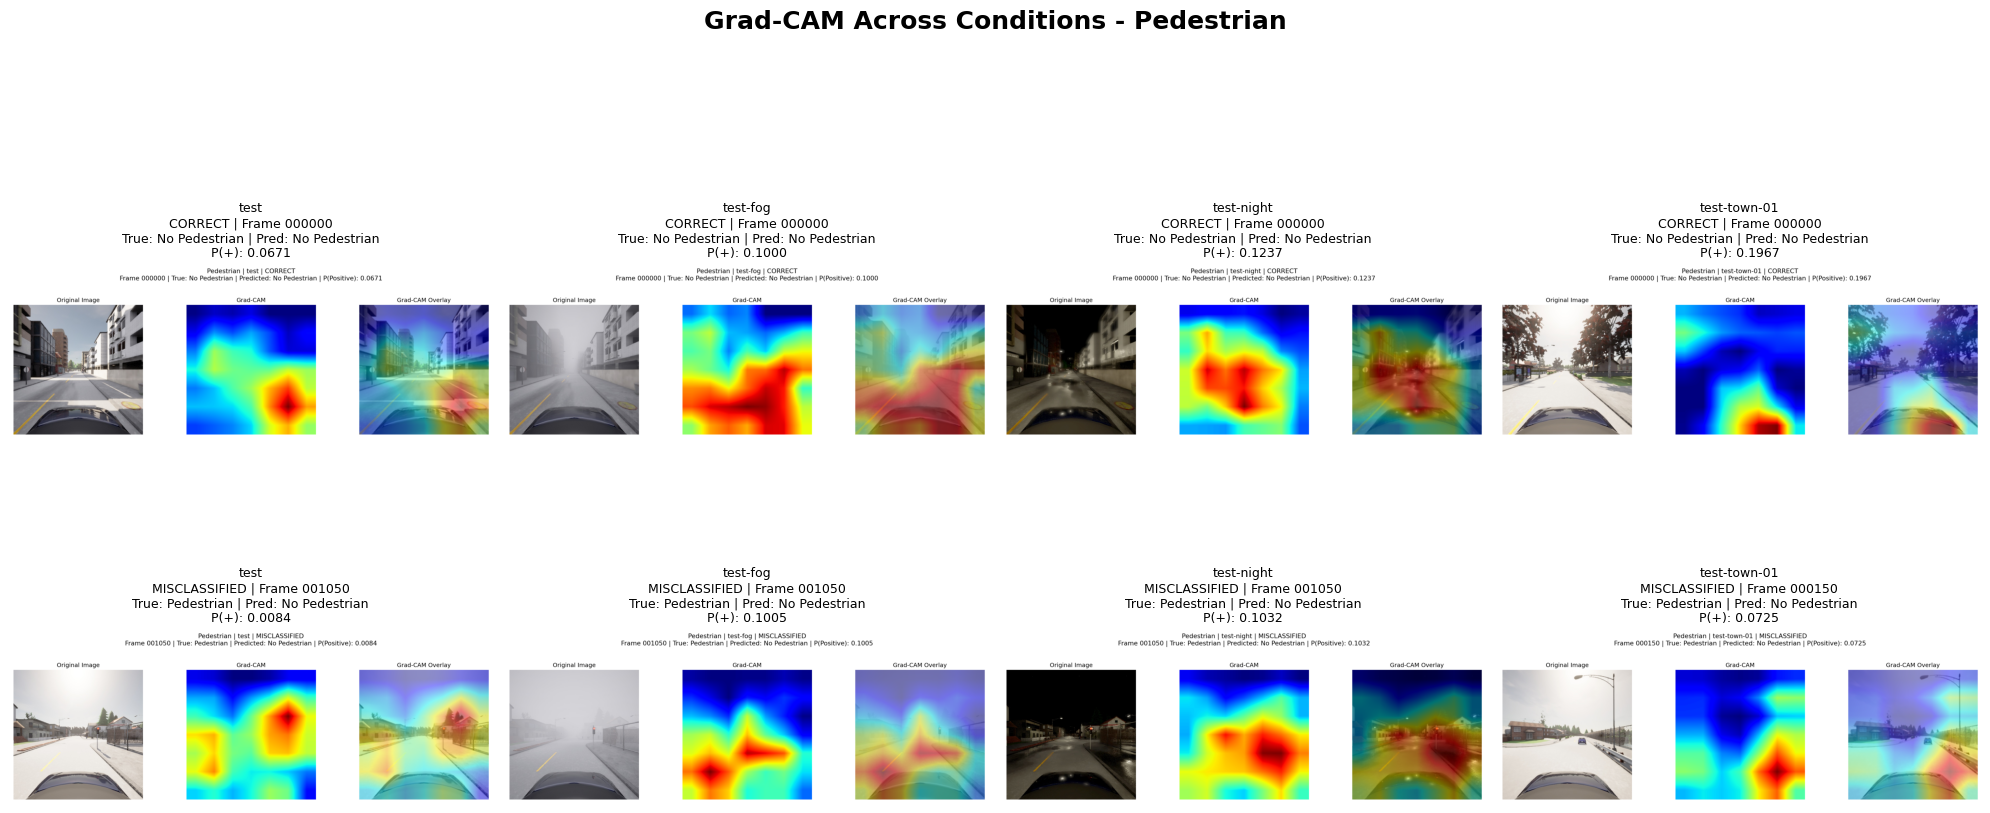

Saved: E:\ML_Safety\explainability_results\condition_comparisons\pedestrian_condition_comparison.png

----------------------------------------------------------------------
MODEL: Traffic Light
----------------------------------------------------------------------


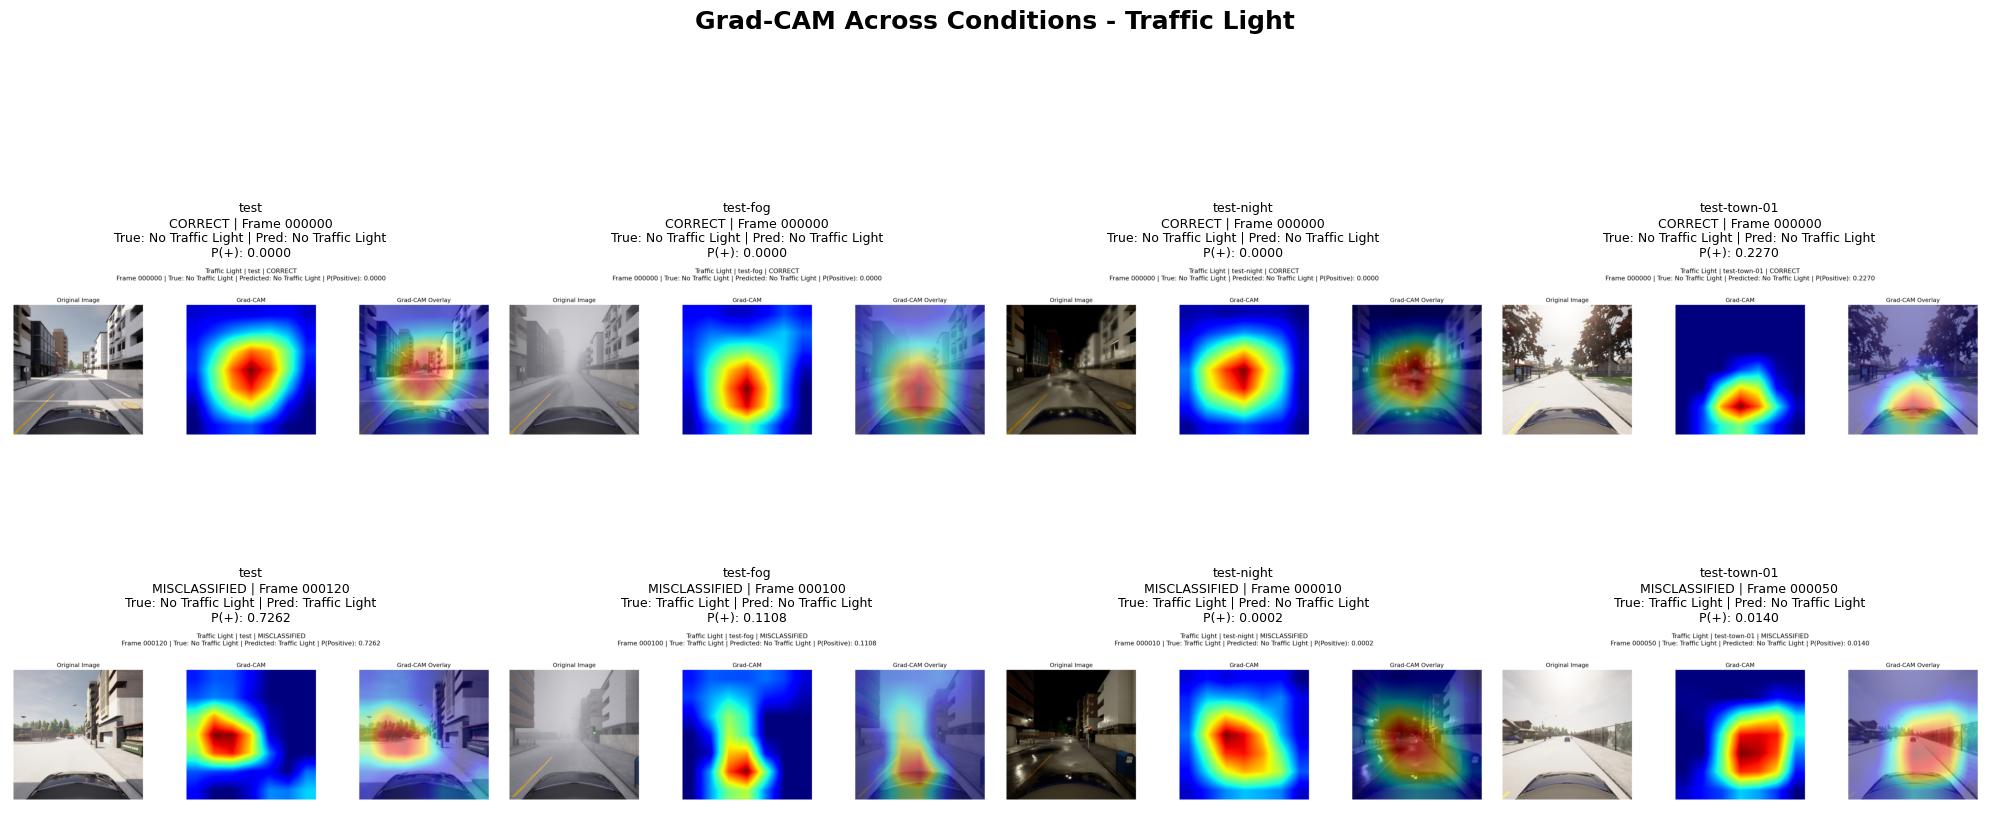

Saved: E:\ML_Safety\explainability_results\condition_comparisons\traffic_light_condition_comparison.png

----------------------------------------------------------------------
MODEL: Vehicle
----------------------------------------------------------------------


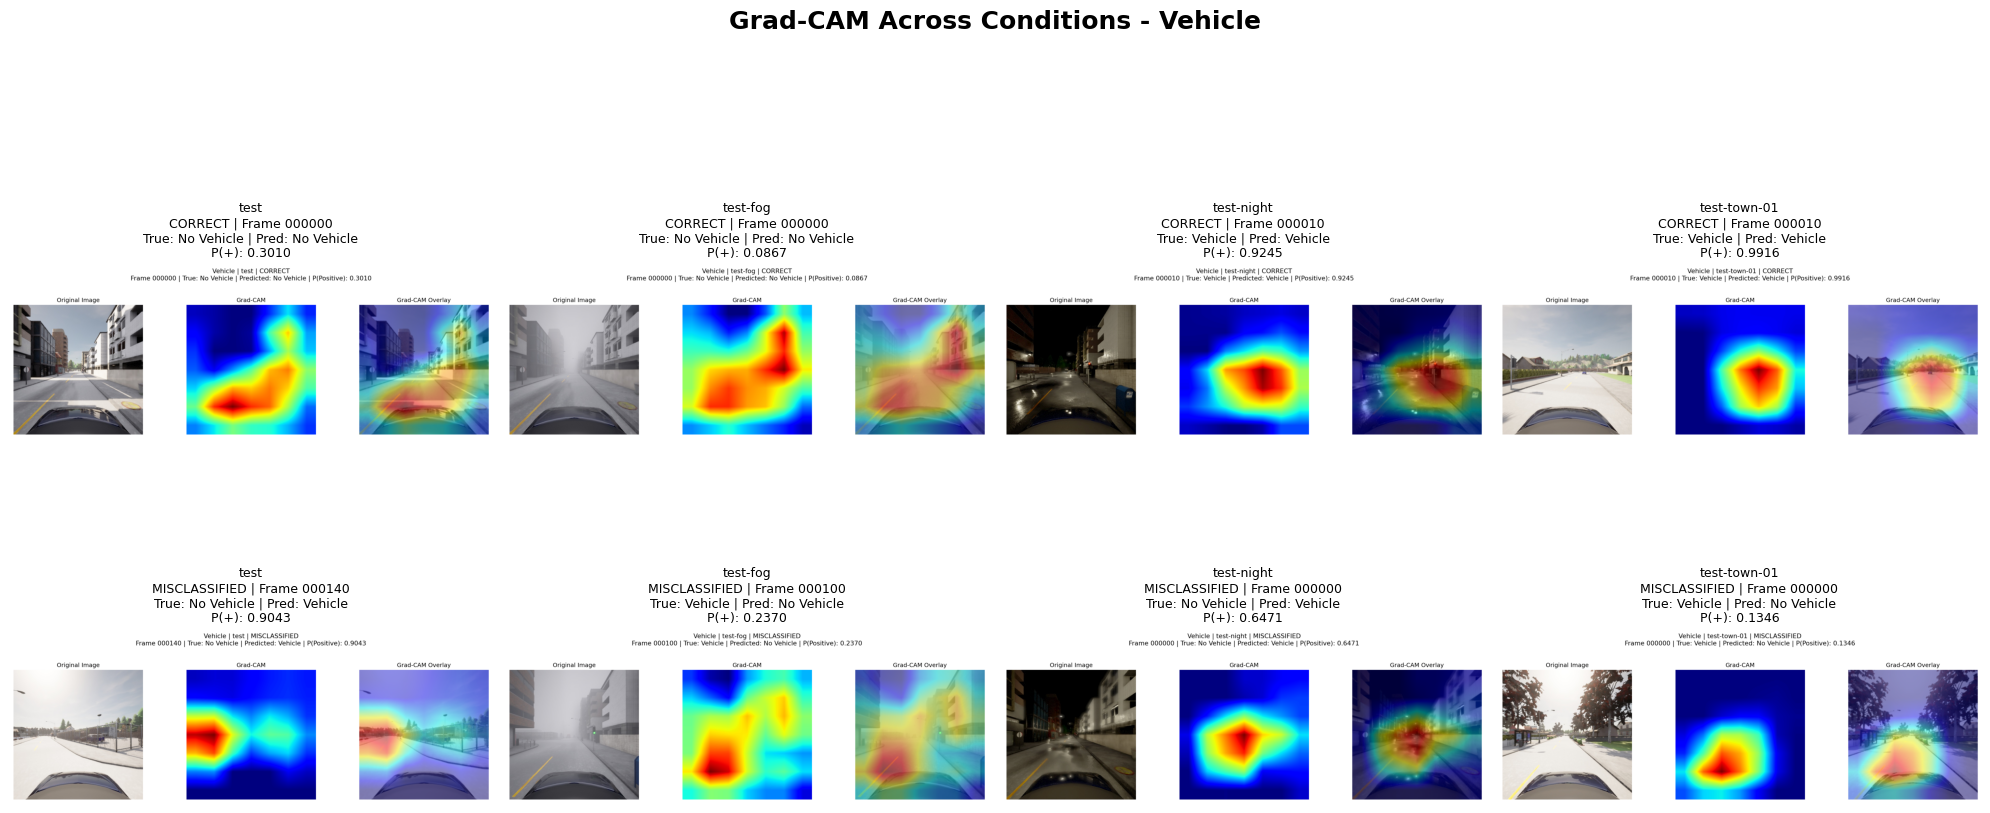

Saved: E:\ML_Safety\explainability_results\condition_comparisons\vehicle_condition_comparison.png

CONDITION COMPARISON COMPLETE
Comparison sheets: 3
E:\ML_Safety\explainability_results\condition_comparisons\pedestrian_condition_comparison.png
E:\ML_Safety\explainability_results\condition_comparisons\traffic_light_condition_comparison.png
E:\ML_Safety\explainability_results\condition_comparisons\vehicle_condition_comparison.png

CELL 12 COMPLETE


In [14]:
# ============================================================
# EXERCISE 6.6 - CELL 12
# CONDITION GRAD-CAM COMPARISON SHEETS
# ============================================================

print("=" * 70)
print("EXERCISE 6.6 - CONDITION GRAD-CAM COMPARISON")
print("=" * 70)

conditions_order = [
    "test",
    "test-fog",
    "test-night",
    "test-town-01"
]

models_order = [
    "Pedestrian",
    "Traffic Light",
    "Vehicle"
]

comparison_dir = os.path.join(
    EXPLAINABILITY_DIR,
    "condition_comparisons"
)

os.makedirs(
    comparison_dir,
    exist_ok=True
)


# ============================================================
# CREATE ONE COMPARISON SHEET PER MODEL
# ============================================================

comparison_paths = []

for model_name in models_order:

    model_records = condition_gradcam_df[
        condition_gradcam_df["model"] == model_name
    ].copy()

    print("\n" + "-" * 70)
    print("MODEL:", model_name)
    print("-" * 70)

    fig, axes = plt.subplots(
        2,
        4,
        figsize=(20, 10)
    )

    for row_number, sample_type in enumerate(
        ["correct", "incorrect"]
    ):

        for col_number, condition_name in enumerate(
            conditions_order
        ):

            ax = axes[
                row_number,
                col_number
            ]

            selected = model_records[
                (model_records["condition"] == condition_name) &
                (model_records["sample_type"] == sample_type)
            ]

            if len(selected) == 0:

                ax.text(
                    0.5,
                    0.5,
                    "No sample",
                    ha="center",
                    va="center"
                )

                ax.axis("off")

                continue

            record = selected.iloc[0]

            image_path = record[
                "output_path"
            ]

            image = Image.open(
                image_path
            )

            ax.imshow(
                image
            )

            true_name = class_name(
                model_name,
                record["true_label"]
            )

            predicted_name = class_name(
                model_name,
                record["prediction"]
            )

            status = (
                "CORRECT"
                if sample_type == "correct"
                else "MISCLASSIFIED"
            )

            ax.set_title(
                (
                    f"{condition_name}\n"
                    f"{status} | Frame "
                    f"{int(record['frame']):06d}\n"
                    f"True: {true_name} | "
                    f"Pred: {predicted_name}\n"
                    f"P(+): "
                    f"{record['probability']:.4f}"
                ),
                fontsize=9
            )

            ax.axis("off")


    fig.suptitle(
        (
            f"Grad-CAM Across Conditions - "
            f"{model_name}"
        ),
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.95]
    )

    safe_model = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    output_path = os.path.join(
        comparison_dir,
        f"{safe_model}_condition_comparison.png"
    )

    plt.savefig(
        output_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    plt.close(fig)

    comparison_paths.append(
        output_path
    )

    print(
        "Saved:",
        output_path
    )


# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("CONDITION COMPARISON COMPLETE")
print("=" * 70)

print(
    "Comparison sheets:",
    len(comparison_paths)
)

for path in comparison_paths:
    print(path)

print("\n" + "=" * 70)
print("CELL 12 COMPLETE")
print("=" * 70)

In [15]:
# ============================================================
# EXERCISE 6.6 - FINAL CONDITION ANALYSIS
# ============================================================

print("=" * 70)
print("EXERCISE 6.6 - FINAL CONDITION ANALYSIS")
print("=" * 70)


# ============================================================
# PERFORMANCE DATA FROM CELL 10
# ============================================================

condition_performance = [
    ["test", "Pedestrian", 0.7914, 0.3834, 0.1048, 0.1646],
    ["test", "Traffic Light", 0.9375, 0.9380, 0.9776, 0.9574],
    ["test", "Vehicle", 0.8842, 0.9152, 0.9319, 0.9235],

    ["test-fog", "Pedestrian", 0.7964, 0.0000, 0.0000, 0.0000],
    ["test-fog", "Traffic Light", 0.7194, 0.9628, 0.6401, 0.7690],
    ["test-fog", "Vehicle", 0.6611, 0.9851, 0.5706, 0.7226],

    ["test-night", "Pedestrian", 0.7881, 0.2281, 0.0178, 0.0330],
    ["test-night", "Traffic Light", 0.2706, 1.0000, 0.0004, 0.0008],
    ["test-night", "Vehicle", 0.8231, 0.8566, 0.9264, 0.8901],

    ["test-town-01", "Pedestrian", 0.8978, 0.3475, 0.1508, 0.2103],
    ["test-town-01", "Traffic Light", 0.7919, 0.8910, 0.7949, 0.8402],
    ["test-town-01", "Vehicle", 0.7342, 0.7420, 0.8507, 0.7926],
]


performance_df = pd.DataFrame(
    condition_performance,
    columns=[
        "Condition",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)


# ============================================================
# DISPLAY COMPLETE TABLE
# ============================================================

print("\nCONDITION PERFORMANCE")
print("-" * 70)

display(
    performance_df
)


# ============================================================
# F1 DEGRADATION RELATIVE TO NORMAL TEST
# ============================================================

baseline = (
    performance_df[
        performance_df["Condition"] == "test"
    ]
    .set_index("Model")
)


analysis_rows = []

for _, row in performance_df.iterrows():

    model = row["Model"]
    condition = row["Condition"]

    baseline_f1 = baseline.loc[
        model,
        "F1"
    ]

    baseline_recall = baseline.loc[
        model,
        "Recall"
    ]

    f1_drop = baseline_f1 - row["F1"]
    recall_drop = baseline_recall - row["Recall"]

    analysis_rows.append([
        condition,
        model,
        row["F1"],
        f1_drop,
        row["Recall"],
        recall_drop
    ])


degradation_df = pd.DataFrame(
    analysis_rows,
    columns=[
        "Condition",
        "Model",
        "F1",
        "F1 Drop",
        "Recall",
        "Recall Drop"
    ]
)


print("\n" + "=" * 70)
print("PERFORMANCE DEGRADATION RELATIVE TO TEST")
print("=" * 70)

display(
    degradation_df
)


# ============================================================
# WORST F1 RESULT
# ============================================================

worst_f1 = performance_df.loc[
    performance_df["F1"].idxmin()
]

print("\n" + "-" * 70)
print("WORST F1 RESULT")
print("-" * 70)

print(
    f"Condition : {worst_f1['Condition']}"
)
print(
    f"Model     : {worst_f1['Model']}"
)
print(
    f"F1 Score  : {worst_f1['F1']:.4f}"
)


# ============================================================
# WORST RECALL RESULT
# ============================================================

worst_recall = performance_df.loc[
    performance_df["Recall"].idxmin()
]

print("\n" + "-" * 70)
print("WORST RECALL RESULT")
print("-" * 70)

print(
    f"Condition : {worst_recall['Condition']}"
)
print(
    f"Model     : {worst_recall['Model']}"
)
print(
    f"Recall    : {worst_recall['Recall']:.4f}"
)


# ============================================================
# LARGEST F1 DEGRADATION
# ============================================================

non_baseline = degradation_df[
    degradation_df["Condition"] != "test"
]

largest_drop = non_baseline.loc[
    non_baseline["F1 Drop"].idxmax()
]

print("\n" + "-" * 70)
print("LARGEST F1 DEGRADATION")
print("-" * 70)

print(
    f"Condition : {largest_drop['Condition']}"
)
print(
    f"Model     : {largest_drop['Model']}"
)
print(
    f"Baseline F1 : "
    f"{baseline.loc[largest_drop['Model'], 'F1']:.4f}"
)
print(
    f"Current F1  : "
    f"{largest_drop['F1']:.4f}"
)
print(
    f"F1 Drop     : "
    f"{largest_drop['F1 Drop']:.4f}"
)


# ============================================================
# SAVE ANALYSIS
# ============================================================

analysis_path = os.path.join(
    EXPLAINABILITY_DIR,
    "condition_performance_analysis.csv"
)

degradation_df.to_csv(
    analysis_path,
    index=False
)

print("\n" + "=" * 70)
print("FINAL CONDITION ANALYSIS COMPLETE")
print("=" * 70)

print(
    "Analysis saved to:",
    analysis_path
)

print("\nCELL 13 COMPLETE")
print("=" * 70)

EXERCISE 6.6 - FINAL CONDITION ANALYSIS

CONDITION PERFORMANCE
----------------------------------------------------------------------


,Condition,Model,Accuracy,Precision,Recall,F1
0,test,Pedestrian,0.7914,0.3834,0.1048,0.1646
1,test,Traffic Light,0.9375,0.9380,0.9776,0.9574
2,test,Vehicle,0.8842,0.9152,0.9319,0.9235
3,test-fog,Pedestrian,0.7964,0.0000,0.0000,0.0000
4,test-fog,Traffic Light,0.7194,0.9628,0.6401,0.7690
5,test-fog,Vehicle,0.6611,0.9851,0.5706,0.7226
6,test-night,Pedestrian,0.7881,0.2281,0.0178,0.0330
7,test-night,Traffic Light,0.2706,1.0000,0.0004,0.0008
8,test-night,Vehicle,0.8231,0.8566,0.9264,0.8901
9,test-town-01,Pedestrian,0.8978,0.3475,0.1508,0.2103



PERFORMANCE DEGRADATION RELATIVE TO TEST


,Condition,Model,F1,F1 Drop,Recall,Recall Drop
0,test,Pedestrian,0.1646,0.0000,0.1048,0.0000
1,test,Traffic Light,0.9574,0.0000,0.9776,0.0000
2,test,Vehicle,0.9235,0.0000,0.9319,0.0000
3,test-fog,Pedestrian,0.0000,0.1646,0.0000,0.1048
4,test-fog,Traffic Light,0.7690,0.1884,0.6401,0.3375
5,test-fog,Vehicle,0.7226,0.2009,0.5706,0.3613
6,test-night,Pedestrian,0.0330,0.1316,0.0178,0.0870
7,test-night,Traffic Light,0.0008,0.9566,0.0004,0.9772
8,test-night,Vehicle,0.8901,0.0334,0.9264,0.0055
9,test-town-01,Pedestrian,0.2103,-0.0457,0.1508,-0.0460



----------------------------------------------------------------------
WORST F1 RESULT
----------------------------------------------------------------------
Condition : test-fog
Model     : Pedestrian
F1 Score  : 0.0000

----------------------------------------------------------------------
WORST RECALL RESULT
----------------------------------------------------------------------
Condition : test-fog
Model     : Pedestrian
Recall    : 0.0000

----------------------------------------------------------------------
LARGEST F1 DEGRADATION
----------------------------------------------------------------------
Condition : test-night
Model     : Traffic Light
Baseline F1 : 0.9574
Current F1  : 0.0008
F1 Drop     : 0.9566

FINAL CONDITION ANALYSIS COMPLETE
Analysis saved to: E:\ML_Safety\explainability_results\condition_performance_analysis.csv

CELL 13 COMPLETE
